In [1]:
#1- Handling Missing Values - IT24100500

In [2]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Load your dataset
file_path = 'C:\\Users\\PASINDU VIHANGA\\Desktop\\SLIIT\\Year 02\\Semester 01\\AI & ML\\AIML Project\\Model_Training\\health_lifestyle_classification.csv'
df = pd.read_csv(file_path)

# Step 3: Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
survey_code                     0
age                             0
gender                          0
height                          0
weight                          0
bmi                             0
bmi_estimated                   0
bmi_scaled                      0
bmi_corrected                   0
waist_size                      0
blood_pressure               7669
heart_rate                  14003
cholesterol                     0
glucose                         0
insulin                     15836
sleep_hours                     0
sleep_quality                   0
work_hours                      0
physical_activity               0
daily_steps                  8329
calorie_intake                  0
sugar_intake                    0
alcohol_consumption         42387
smoking_level                   0
water_intake                    0
screen_time                     0
stress_level                    0
mental_health_score             0
mental_health_support

Missing values per column:
survey_code                     0
age                             0
gender                          0
height                          0
weight                          0
bmi                             0
bmi_estimated                   0
bmi_scaled                      0
bmi_corrected                   0
waist_size                      0
blood_pressure               7669
heart_rate                  14003
cholesterol                     0
glucose                         0
insulin                     15836
sleep_hours                     0
sleep_quality                   0
work_hours                      0
physical_activity               0
daily_steps                  8329
calorie_intake                  0
sugar_intake                    0
alcohol_consumption         42387
smoking_level                   0
water_intake                    0
screen_time                     0
stress_level                    0
mental_health_score             0
mental_health_support

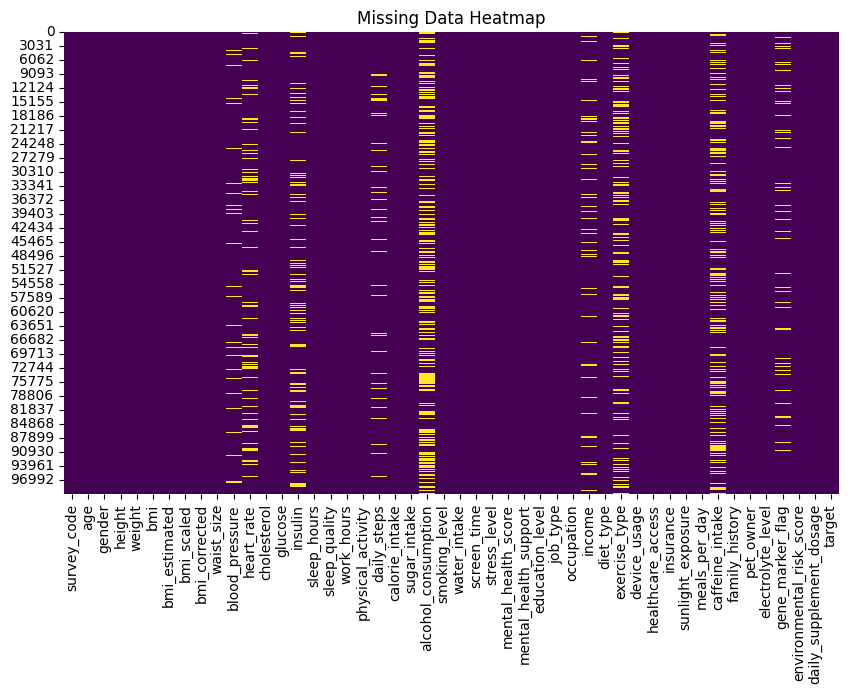


Processing column: heart_rate
Original missing: 14003, Mean used: 74.97


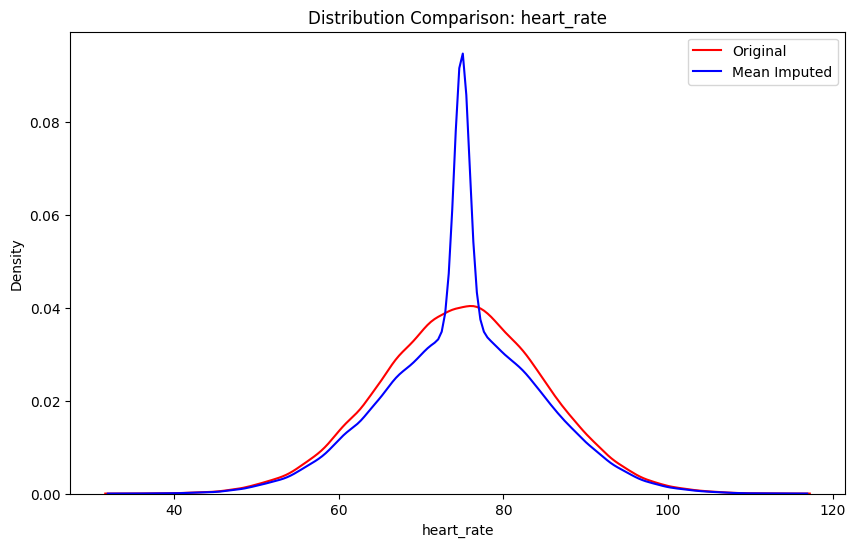


Processing column: blood_pressure
Original missing: 7669, Mean used: 119.98


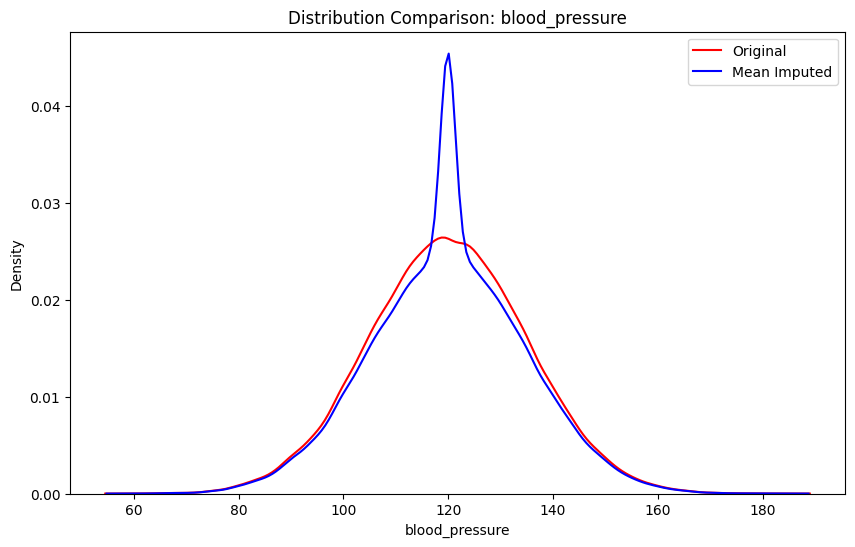


Processing column: daily_steps
Original missing: 8329, Mean used: 7012.93


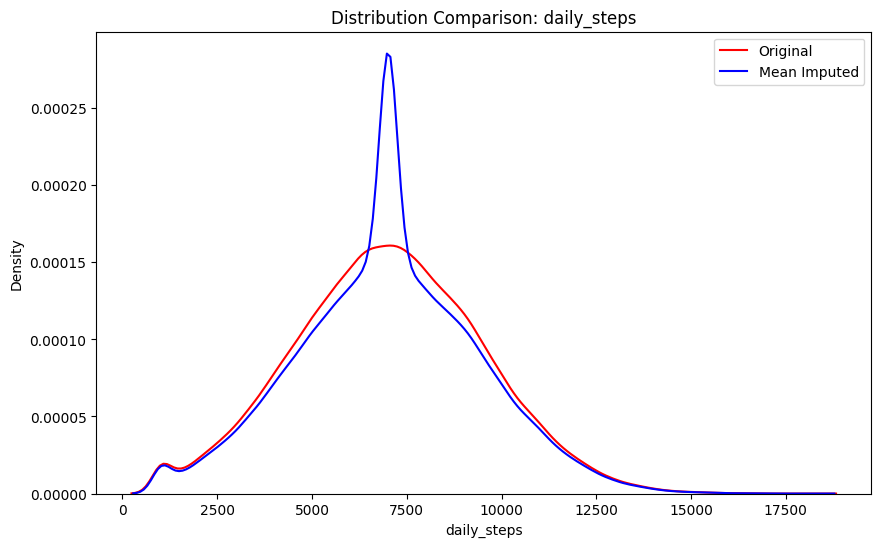

In [3]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Load your dataset
file_path = 'C:\\Users\\PASINDU VIHANGA\\Desktop\\SLIIT\\Year 02\\Semester 01\\AI & ML\\AIML Project\\Model_Training\\health_lifestyle_classification.csv'
df = pd.read_csv(file_path)

# Step 3: Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Step 4: Visualize missing data
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

# Step 5: Define target columns
target_cols = ['heart_rate', 'blood_pressure', 'daily_steps']

# Step 6: Impute and compare distributions
for col in target_cols:
    print(f"\nProcessing column: {col}")
    
    # Convert to numeric (coerce errors to NaN)
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Fill missing values with mean
    mean_value = df[col].mean()
    imputed_col = col + '_mean'
    df[imputed_col] = df[col].fillna(mean_value)
    
    # Print summary stats
    print(f"Original missing: {df[col].isnull().sum()}, Mean used: {mean_value:.2f}")
    
    # Plot distributions if variance exists
    plt.figure(figsize=(10, 6))
    plotted = False
    if df[col].var() > 0:
        sns.kdeplot(df[col], label='Original', color='red')
        plotted = True
    else:
        print(f"Skipping KDE for {col} due to zero variance.")
    
    if df[imputed_col].var() > 0:
        sns.kdeplot(df[imputed_col], label='Mean Imputed', color='blue')
        plotted = True
    else:
        print(f"Skipping KDE for {imputed_col} due to zero variance.")
    
    if plotted:
        plt.title(f'Distribution Comparison: {col}')
        plt.legend()
        plt.show()


In [4]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
survey_code                     0
age                             0
gender                          0
height                          0
weight                          0
bmi                             0
bmi_estimated                   0
bmi_scaled                      0
bmi_corrected                   0
waist_size                      0
blood_pressure               7669
heart_rate                  14003
cholesterol                     0
glucose                         0
insulin                     15836
sleep_hours                     0
sleep_quality                   0
work_hours                      0
physical_activity               0
daily_steps                  8329
calorie_intake                  0
sugar_intake                    0
alcohol_consumption         42387
smoking_level                   0
water_intake                    0
screen_time                     0
stress_level                    0
mental_health_score             0
mental_health_support

In [5]:
# Define original columns to drop
original_cols = ['heart_rate', 'blood_pressure', 'daily_steps']

# Drop them from the DataFrame
df.drop(columns=original_cols, inplace=True)

# Confirm they're gone
print("Remaining columns:")
print(df.columns)

Remaining columns:
Index(['survey_code', 'age', 'gender', 'height', 'weight', 'bmi',
       'bmi_estimated', 'bmi_scaled', 'bmi_corrected', 'waist_size',
       'cholesterol', 'glucose', 'insulin', 'sleep_hours', 'sleep_quality',
       'work_hours', 'physical_activity', 'calorie_intake', 'sugar_intake',
       'alcohol_consumption', 'smoking_level', 'water_intake', 'screen_time',
       'stress_level', 'mental_health_score', 'mental_health_support',
       'education_level', 'job_type', 'occupation', 'income', 'diet_type',
       'exercise_type', 'device_usage', 'healthcare_access', 'insurance',
       'sunlight_exposure', 'meals_per_day', 'caffeine_intake',
       'family_history', 'pet_owner', 'electrolyte_level', 'gene_marker_flag',
       'environmental_risk_score', 'daily_supplement_dosage', 'target',
       'heart_rate_mean', 'blood_pressure_mean', 'daily_steps_mean'],
      dtype='object')


In [6]:
df.rename(columns={
    'heart_rate_mean': 'heart_rate',
    'blood_pressure_mean': 'blood_pressure',
    'daily_steps_mean': 'daily_steps'
}, inplace=True)

# ✅ Confirm the change
print("Updated column names:")
print(df.columns)

Updated column names:
Index(['survey_code', 'age', 'gender', 'height', 'weight', 'bmi',
       'bmi_estimated', 'bmi_scaled', 'bmi_corrected', 'waist_size',
       'cholesterol', 'glucose', 'insulin', 'sleep_hours', 'sleep_quality',
       'work_hours', 'physical_activity', 'calorie_intake', 'sugar_intake',
       'alcohol_consumption', 'smoking_level', 'water_intake', 'screen_time',
       'stress_level', 'mental_health_score', 'mental_health_support',
       'education_level', 'job_type', 'occupation', 'income', 'diet_type',
       'exercise_type', 'device_usage', 'healthcare_access', 'insurance',
       'sunlight_exposure', 'meals_per_day', 'caffeine_intake',
       'family_history', 'pet_owner', 'electrolyte_level', 'gene_marker_flag',
       'environmental_risk_score', 'daily_supplement_dosage', 'target',
       'heart_rate', 'blood_pressure', 'daily_steps'],
      dtype='object')


In [7]:
# Define original columns to drop
original_cols = ['insulin', 'alcohol_consumption', 'income','caffeine_intake','gene_marker_flag','exercise_type']

# Drop them from the DataFrame
df.drop(columns=original_cols, inplace=True)

# Confirm they're gone
print("Remaining columns:")
print(df.columns)

Remaining columns:
Index(['survey_code', 'age', 'gender', 'height', 'weight', 'bmi',
       'bmi_estimated', 'bmi_scaled', 'bmi_corrected', 'waist_size',
       'cholesterol', 'glucose', 'sleep_hours', 'sleep_quality', 'work_hours',
       'physical_activity', 'calorie_intake', 'sugar_intake', 'smoking_level',
       'water_intake', 'screen_time', 'stress_level', 'mental_health_score',
       'mental_health_support', 'education_level', 'job_type', 'occupation',
       'diet_type', 'device_usage', 'healthcare_access', 'insurance',
       'sunlight_exposure', 'meals_per_day', 'family_history', 'pet_owner',
       'electrolyte_level', 'environmental_risk_score',
       'daily_supplement_dosage', 'target', 'heart_rate', 'blood_pressure',
       'daily_steps'],
      dtype='object')


In [8]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
survey_code                 0
age                         0
gender                      0
height                      0
weight                      0
bmi                         0
bmi_estimated               0
bmi_scaled                  0
bmi_corrected               0
waist_size                  0
cholesterol                 0
glucose                     0
sleep_hours                 0
sleep_quality               0
work_hours                  0
physical_activity           0
calorie_intake              0
sugar_intake                0
smoking_level               0
water_intake                0
screen_time                 0
stress_level                0
mental_health_score         0
mental_health_support       0
education_level             0
job_type                    0
occupation                  0
diet_type                   0
device_usage                0
healthcare_access           0
insurance                   0
sunlight_exposure           0
meals_per_day

In [9]:
df =df.dropna()
df.count()

survey_code                 100000
age                         100000
gender                      100000
height                      100000
weight                      100000
bmi                         100000
bmi_estimated               100000
bmi_scaled                  100000
bmi_corrected               100000
waist_size                  100000
cholesterol                 100000
glucose                     100000
sleep_hours                 100000
sleep_quality               100000
work_hours                  100000
physical_activity           100000
calorie_intake              100000
sugar_intake                100000
smoking_level               100000
water_intake                100000
screen_time                 100000
stress_level                100000
mental_health_score         100000
mental_health_support       100000
education_level             100000
job_type                    100000
occupation                  100000
diet_type                   100000
device_usage        

In [10]:
#2- Encoding Categorical Varaibles - IT24100546 

In [11]:
import pandas as pd
# Now this will work
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)


Categorical columns: ['gender', 'sleep_quality', 'smoking_level', 'mental_health_support', 'education_level', 'job_type', 'occupation', 'diet_type', 'device_usage', 'healthcare_access', 'insurance', 'sunlight_exposure', 'family_history', 'pet_owner', 'target']


In [12]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['gender_encoded'] = le.fit_transform(df['gender'])


In [13]:
df['sleep_quality']

0             Fair
1             Good
2             Poor
3             Good
4             Good
           ...    
99995         Poor
99996    Excellent
99997         Good
99998         Fair
99999         Fair
Name: sleep_quality, Length: 100000, dtype: object

In [14]:
from sklearn.preprocessing import OrdinalEncoder

# Define the correct category order for a single column
slp_quality = ['Poor', 'Fair', 'Good', 'Excellent']

# Wrap it in another list to match the expected format for one column
oe = OrdinalEncoder(categories=[slp_quality])

# Apply encoding
df['sleep_quality_encoded'] = oe.fit_transform(df[['sleep_quality']])


In [15]:
df['sleep_quality_encoded']

0        1.0
1        2.0
2        0.0
3        2.0
4        2.0
        ... 
99995    0.0
99996    3.0
99997    2.0
99998    1.0
99999    1.0
Name: sleep_quality_encoded, Length: 100000, dtype: float64

In [16]:
df['smoking_level']

0        Non-smoker
1             Light
2             Heavy
3             Heavy
4             Heavy
            ...    
99995         Light
99996         Light
99997         Heavy
99998    Non-smoker
99999    Non-smoker
Name: smoking_level, Length: 100000, dtype: object

In [17]:
from sklearn.preprocessing import OrdinalEncoder

# Define the correct category order for a single column
smk_lvl = ['Non-smoker', 'Light', 'Heavy']

# Wrap it in another list to match the expected format for one column
oe = OrdinalEncoder(categories=[smk_lvl])

# Apply encoding
df['smoking_level_encoded'] = oe.fit_transform(df[['smoking_level']])


In [18]:
df['smoking_level_encoded']

0        0.0
1        1.0
2        2.0
3        2.0
4        2.0
        ... 
99995    1.0
99996    1.0
99997    2.0
99998    0.0
99999    0.0
Name: smoking_level_encoded, Length: 100000, dtype: float64

In [19]:
df['mental_health_support']

0         No
1         No
2         No
3         No
4        Yes
        ... 
99995     No
99996     No
99997    Yes
99998    Yes
99999    Yes
Name: mental_health_support, Length: 100000, dtype: object

In [20]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['mental_health_support_encoded'] = le.fit_transform(df['mental_health_support'])

In [21]:
df['education_level']

0                PhD
1        High School
2             Master
3             Master
4             Master
            ...     
99995       Bachelor
99996       Bachelor
99997            PhD
99998         Master
99999            PhD
Name: education_level, Length: 100000, dtype: object

In [22]:
from sklearn.preprocessing import OrdinalEncoder

# Define the correct category order for a single column
edu_lvl = ['High School', 'Bachelor', 'Master','PhD']

# Wrap it in another list to match the expected format for one column
oe = OrdinalEncoder(categories=[edu_lvl])

# Apply encoding
df['education_level_encoded'] = oe.fit_transform(df[['education_level']])

In [23]:
df['education_level_encoded']

0        3.0
1        0.0
2        2.0
3        2.0
4        2.0
        ... 
99995    1.0
99996    1.0
99997    3.0
99998    2.0
99999    3.0
Name: education_level_encoded, Length: 100000, dtype: float64

In [24]:
df = pd.get_dummies(df, columns=['job_type', 'diet_type','occupation',], drop_first=True)

In [25]:
df['device_usage']

0            High
1        Moderate
2            High
3             Low
4             Low
           ...   
99995    Moderate
99996        High
99997         Low
99998         Low
99999         Low
Name: device_usage, Length: 100000, dtype: object

In [26]:
from sklearn.preprocessing import OrdinalEncoder

# Define the correct category order for a single column
dev_usg = ['Low', 'Moderate', 'High']

# Wrap it in another list to match the expected format for one column
oe = OrdinalEncoder(categories=[dev_usg])

# Apply encoding
df['device_usage_encoded'] = oe.fit_transform(df[['device_usage']])

In [27]:
df['healthcare_access']

0            Poor
1        Moderate
2            Good
3        Moderate
4        Moderate
           ...   
99995        Poor
99996    Moderate
99997        Good
99998        Poor
99999    Moderate
Name: healthcare_access, Length: 100000, dtype: object

In [28]:
from sklearn.preprocessing import OrdinalEncoder

# Define the correct category order for a single column
hlt_accs = ['Poor', 'Moderate', 'Good']

# Wrap it in another list to match the expected format for one column
oe = OrdinalEncoder(categories=[hlt_accs])

# Apply encoding
df['healthcare_access_encoded'] = oe.fit_transform(df[['healthcare_access']])

In [29]:
df['healthcare_access_encoded']

0        0.0
1        1.0
2        2.0
3        1.0
4        1.0
        ... 
99995    0.0
99996    1.0
99997    2.0
99998    0.0
99999    1.0
Name: healthcare_access_encoded, Length: 100000, dtype: float64

In [30]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['insurance_encoded'] = le.fit_transform(df['insurance'])

In [31]:
df['insurance_encoded']

0        0
1        0
2        1
3        0
4        1
        ..
99995    0
99996    0
99997    1
99998    1
99999    0
Name: insurance_encoded, Length: 100000, dtype: int64

In [32]:
df['sunlight_exposure']

0            High
1            High
2            High
3            High
4            High
           ...   
99995    Moderate
99996    Moderate
99997         Low
99998         Low
99999        High
Name: sunlight_exposure, Length: 100000, dtype: object

In [33]:
from sklearn.preprocessing import OrdinalEncoder

# Define the correct category order for a single column
sun_exp = ['Low', 'Moderate', 'High']

# Wrap it in another list to match the expected format for one column
oe = OrdinalEncoder(categories=[sun_exp])

# Apply encoding
df['sunlight_exposure_encoded'] = oe.fit_transform(df[['sunlight_exposure']])

In [34]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['family_history_encoded'] = le.fit_transform(df['family_history'])

In [35]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['pet_owner_encoded'] = le.fit_transform(df['pet_owner'])

In [36]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['target_encoded'] = le.fit_transform(df['target'])

In [37]:
print(df.columns)

Index(['survey_code', 'age', 'gender', 'height', 'weight', 'bmi',
       'bmi_estimated', 'bmi_scaled', 'bmi_corrected', 'waist_size',
       'cholesterol', 'glucose', 'sleep_hours', 'sleep_quality', 'work_hours',
       'physical_activity', 'calorie_intake', 'sugar_intake', 'smoking_level',
       'water_intake', 'screen_time', 'stress_level', 'mental_health_score',
       'mental_health_support', 'education_level', 'device_usage',
       'healthcare_access', 'insurance', 'sunlight_exposure', 'meals_per_day',
       'family_history', 'pet_owner', 'electrolyte_level',
       'environmental_risk_score', 'daily_supplement_dosage', 'target',
       'heart_rate', 'blood_pressure', 'daily_steps', 'gender_encoded',
       'sleep_quality_encoded', 'smoking_level_encoded',
       'mental_health_support_encoded', 'education_level_encoded',
       'job_type_Labor', 'job_type_Office', 'job_type_Service',
       'job_type_Tech', 'job_type_Unemployed', 'diet_type_Omnivore',
       'diet_type_Vegan'

In [38]:
#3- Outlier Detection and Removal - IT24100488

In [39]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    print(f"{column}: Removed {df.shape[0] - filtered_df.shape[0]} outliers")
    return filtered_df


In [40]:
df.head()

,survey_code,age,gender,height,weight,bmi,bmi_estimated,bmi_scaled,bmi_corrected,waist_size,...,occupation_Engineer,occupation_Farmer,occupation_Teacher,device_usage_encoded,healthcare_access_encoded,insurance_encoded,sunlight_exposure_encoded,family_history_encoded,pet_owner_encoded,target_encoded
0,1,56,Male,173.416872,56.886640,18.915925,18.915925,56.747776,18.989117,72.165130,...,False,True,False,2.0,0.0,0,2.0,0,1,1
1,2,69,Female,163.207380,97.799859,36.716278,36.716278,110.148833,36.511417,85.598889,...,True,False,False,1.0,1.0,0,2.0,1,0,1
2,3,46,Male,177.281966,80.687562,25.673050,25.673050,77.019151,25.587429,90.295030,...,False,False,True,2.0,2.0,1,2.0,0,0,1
3,4,32,Female,172.101255,63.142868,21.318480,21.318480,63.955440,21.177109,100.504211,...,False,False,True,0.0,1.0,0,2.0,0,1,1
4,5,60,Female,163.608816,40.000000,14.943302,14.943302,44.829907,14.844299,69.021150,...,False,False,False,0.0,1.0,1,2.0,1,1,1


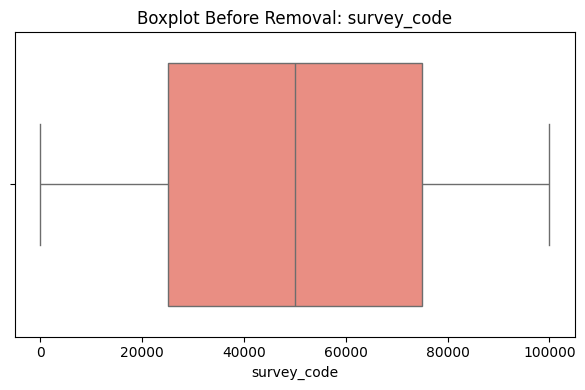

survey_code: Removed 0 outliers


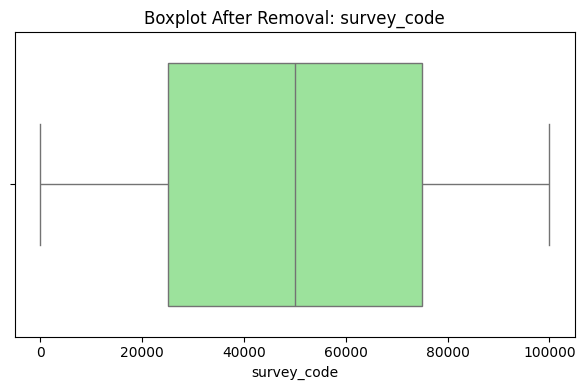

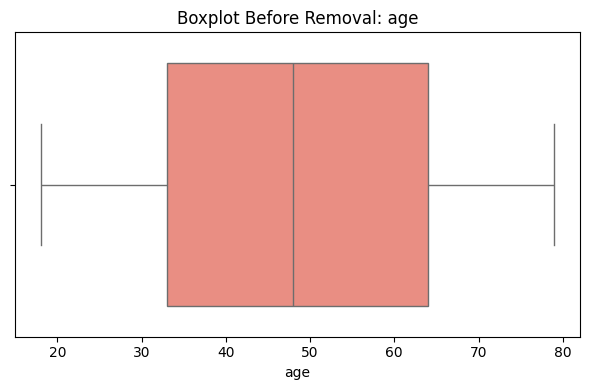

age: Removed 0 outliers


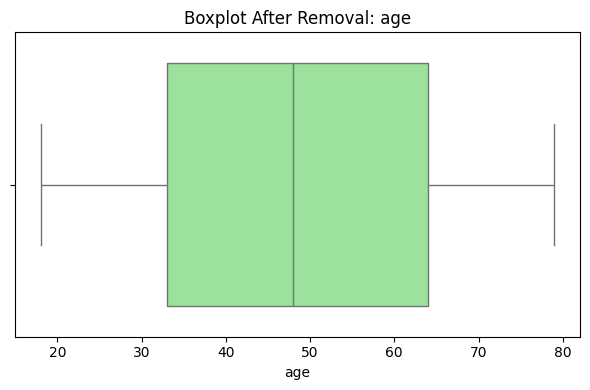

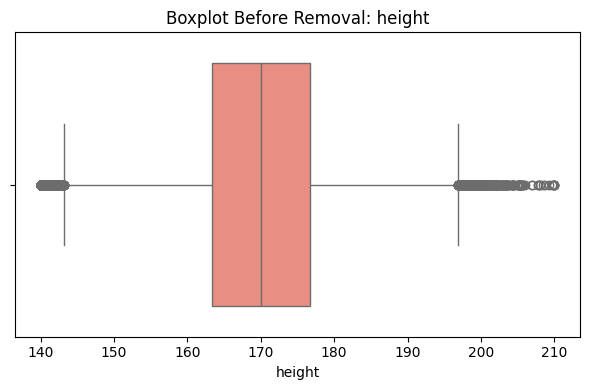

height: Removed 750 outliers


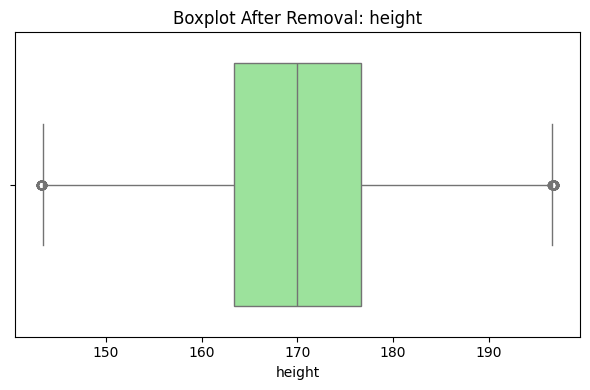

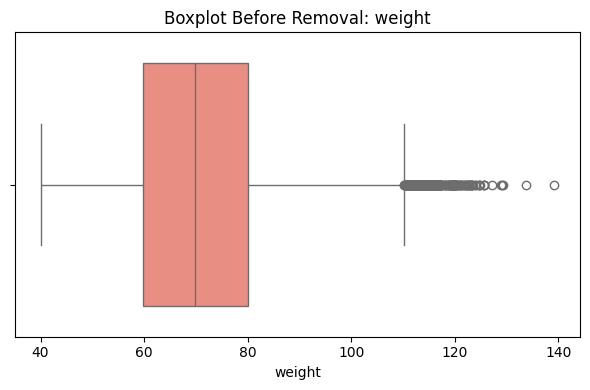

weight: Removed 333 outliers


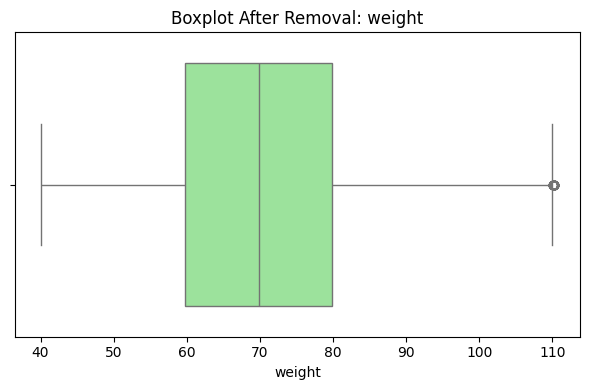

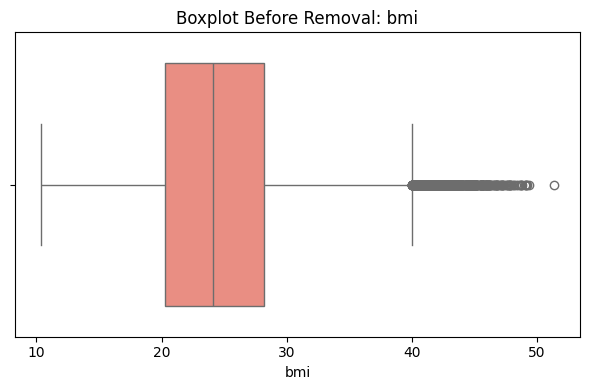

bmi: Removed 746 outliers


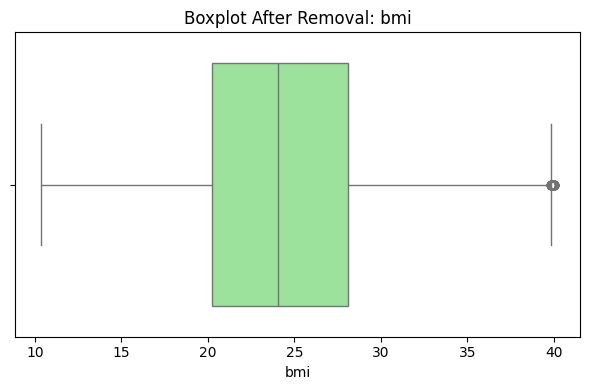

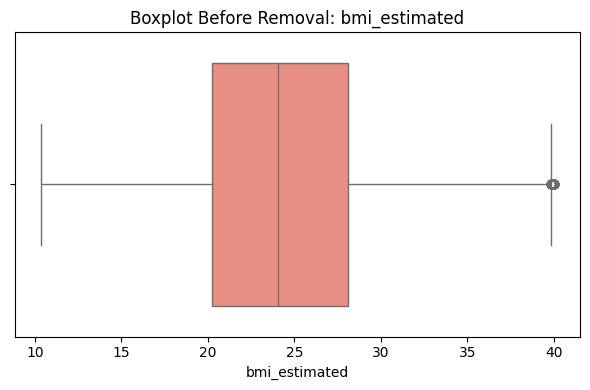

bmi_estimated: Removed 62 outliers


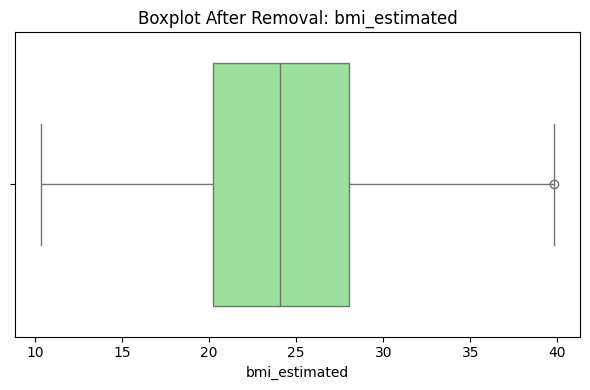

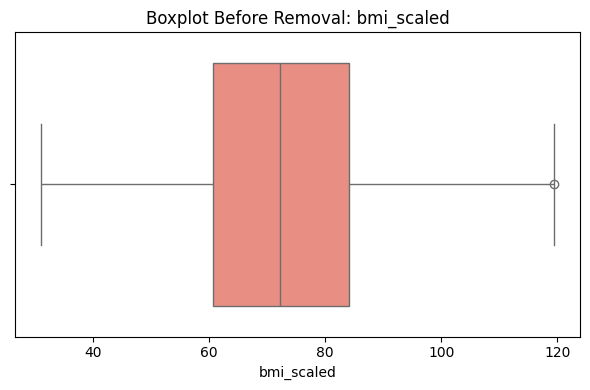

bmi_scaled: Removed 1 outliers


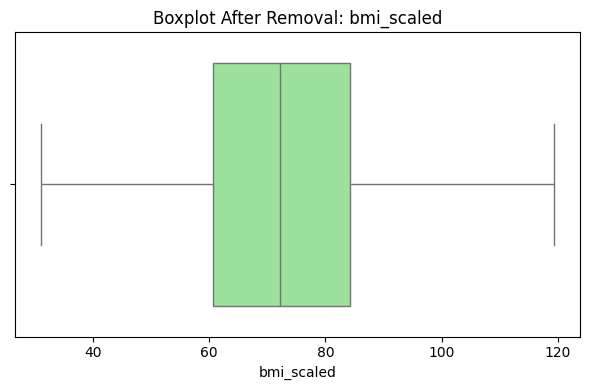

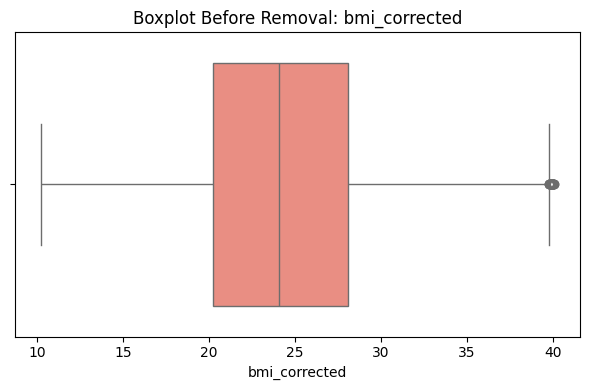

bmi_corrected: Removed 32 outliers


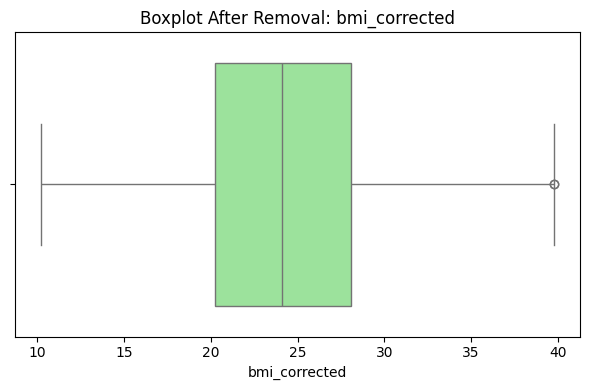

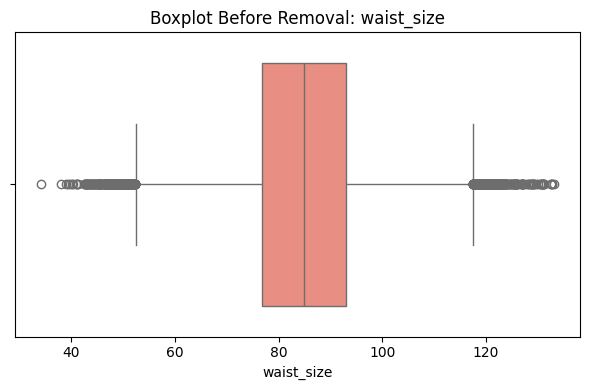

waist_size: Removed 685 outliers


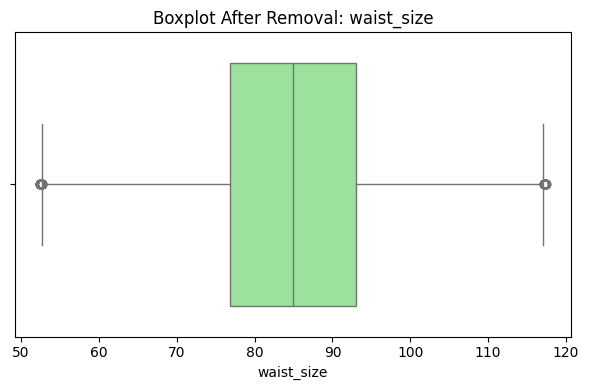

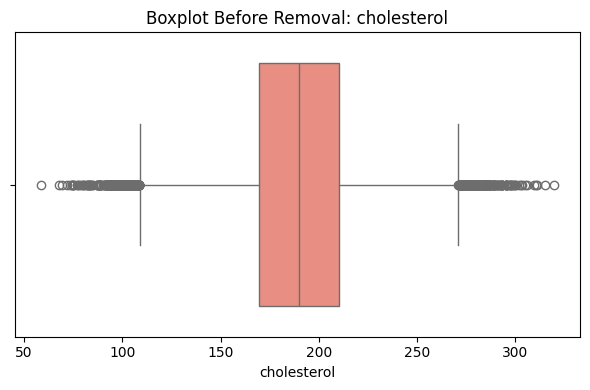

cholesterol: Removed 656 outliers


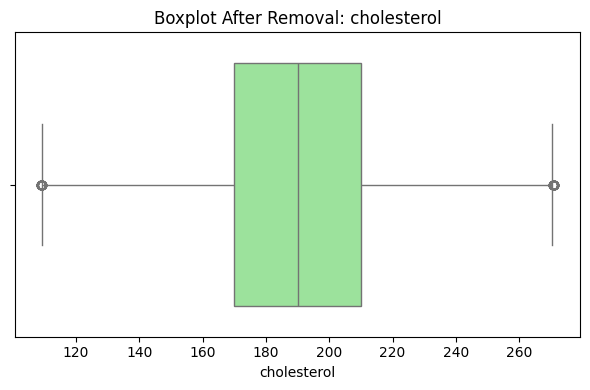

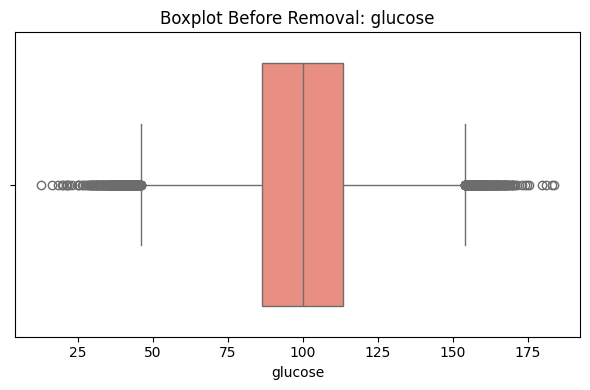

glucose: Removed 651 outliers


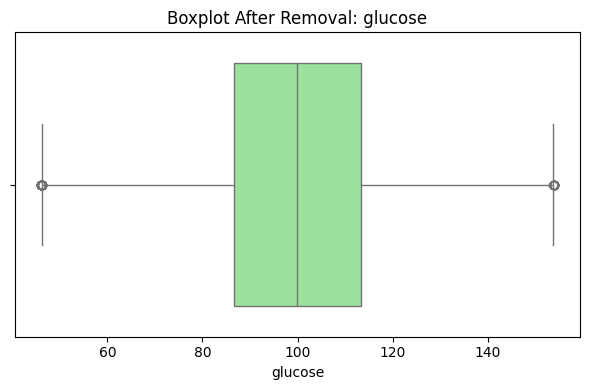

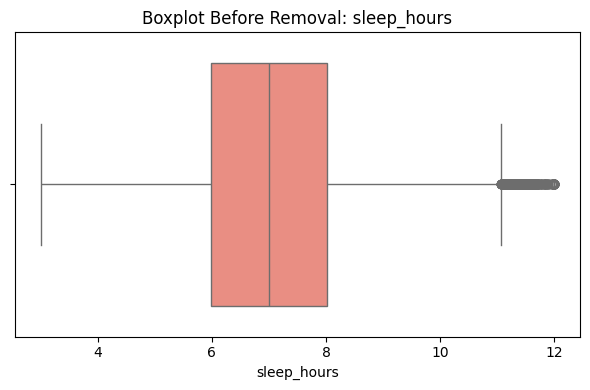

sleep_hours: Removed 314 outliers


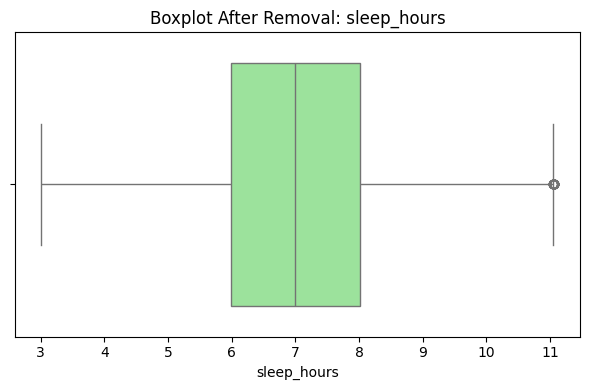

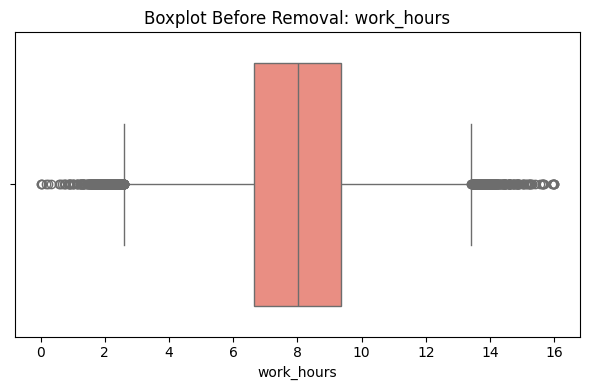

work_hours: Removed 590 outliers


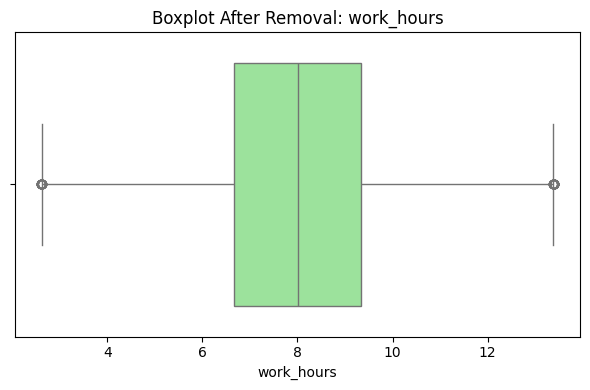

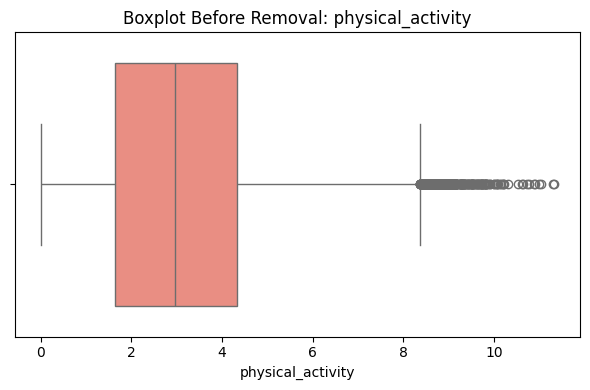

physical_activity: Removed 330 outliers


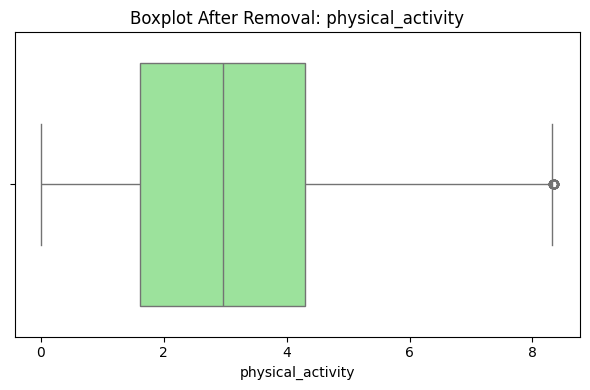

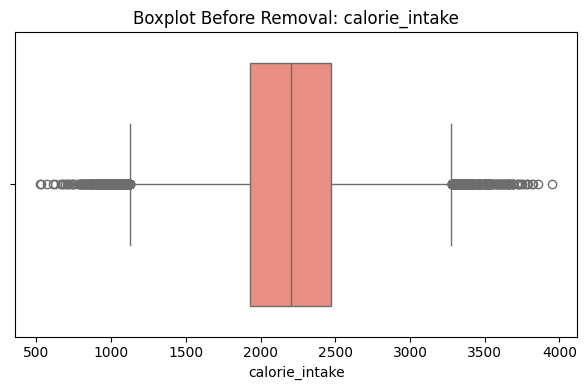

calorie_intake: Removed 705 outliers


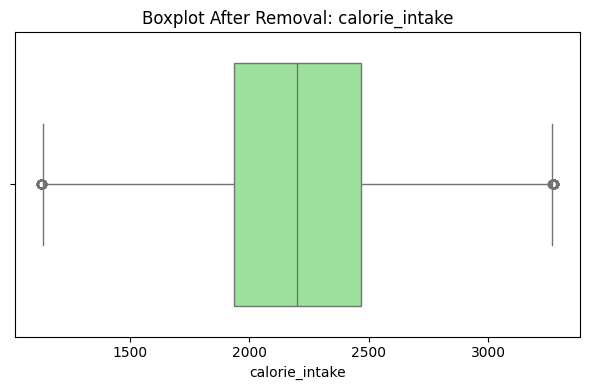

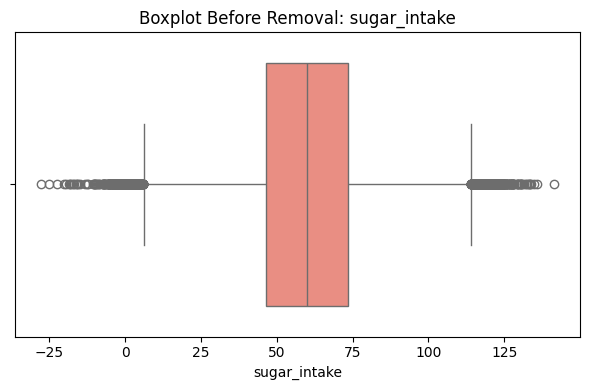

sugar_intake: Removed 651 outliers


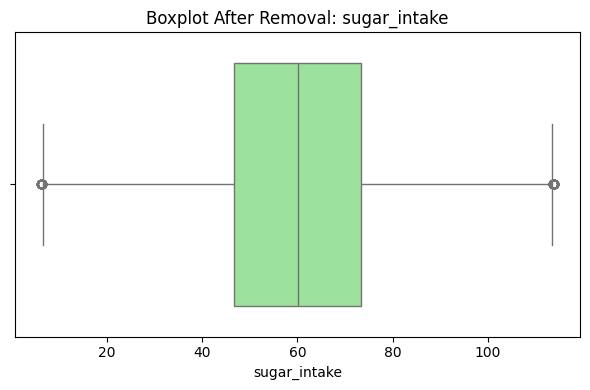

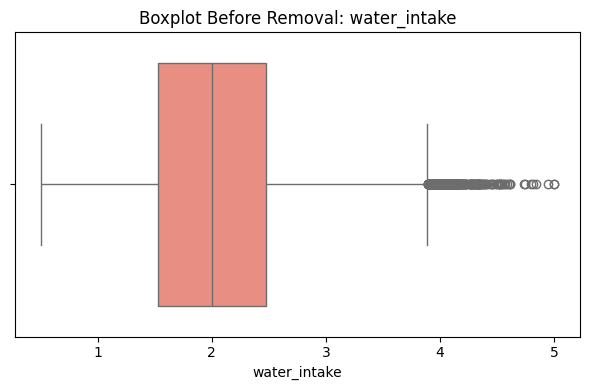

water_intake: Removed 319 outliers


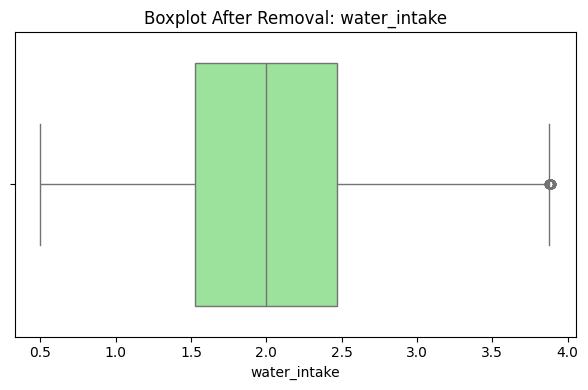

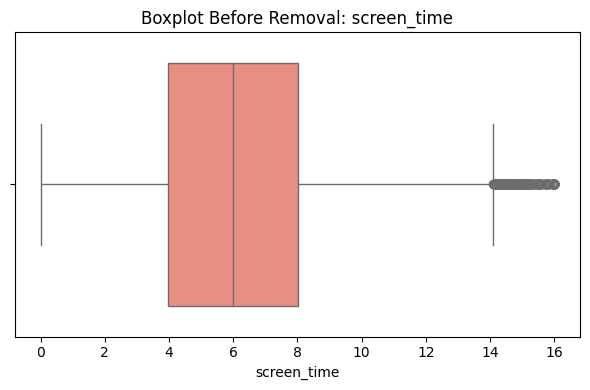

screen_time: Removed 318 outliers


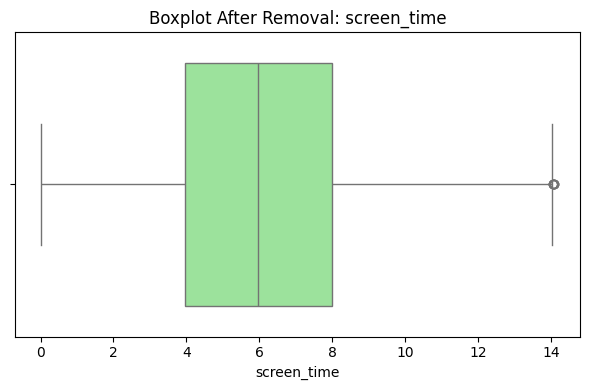

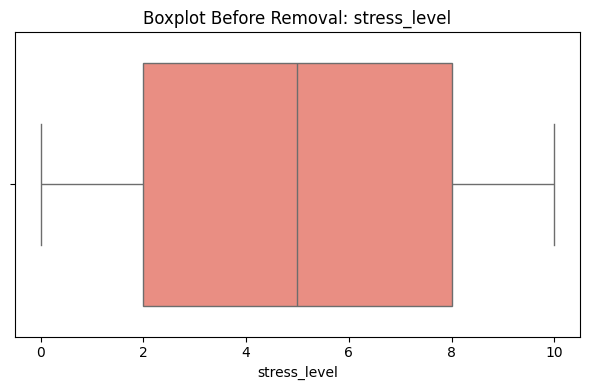

stress_level: Removed 0 outliers


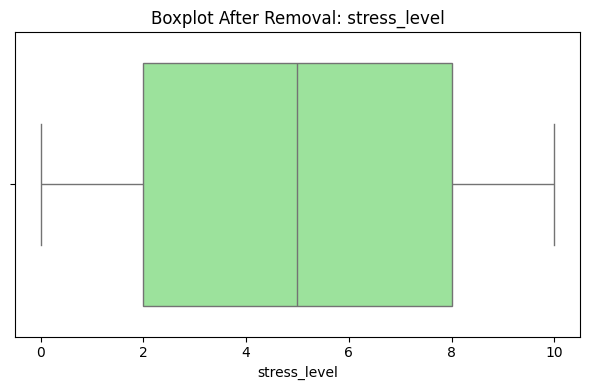

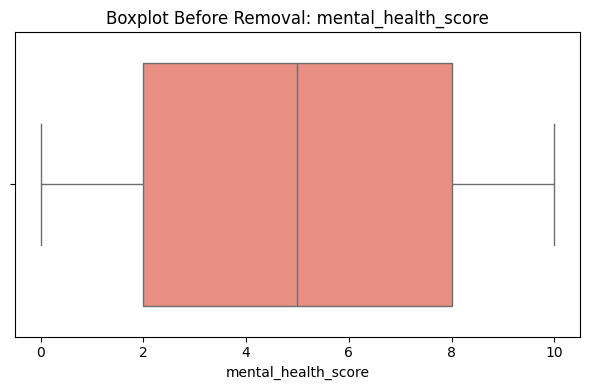

mental_health_score: Removed 0 outliers


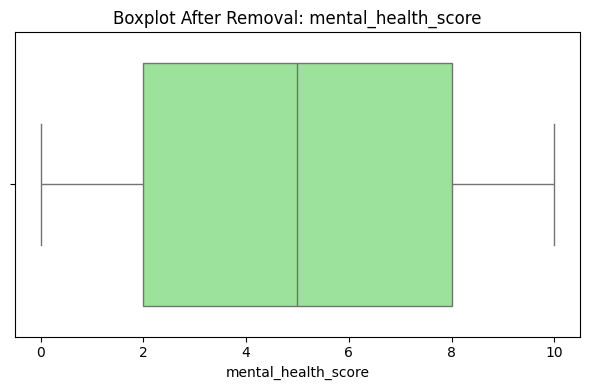

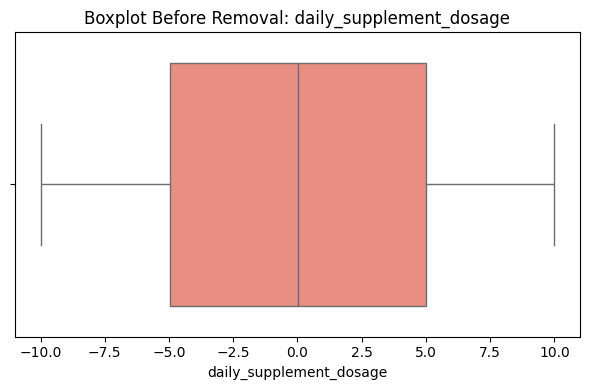

daily_supplement_dosage: Removed 0 outliers


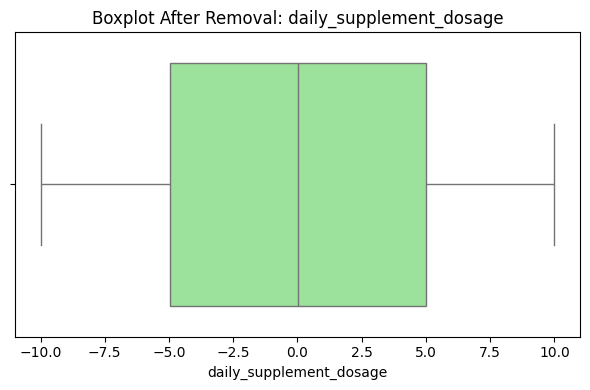

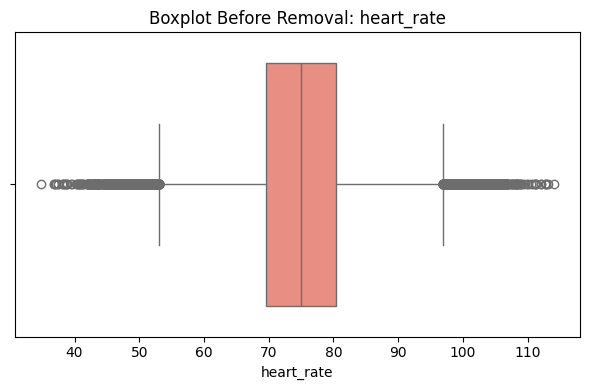

heart_rate: Removed 2247 outliers


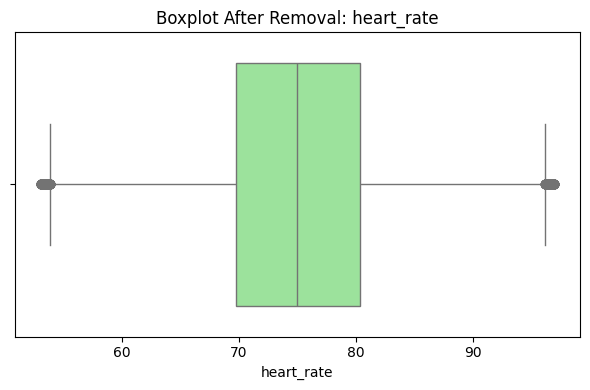

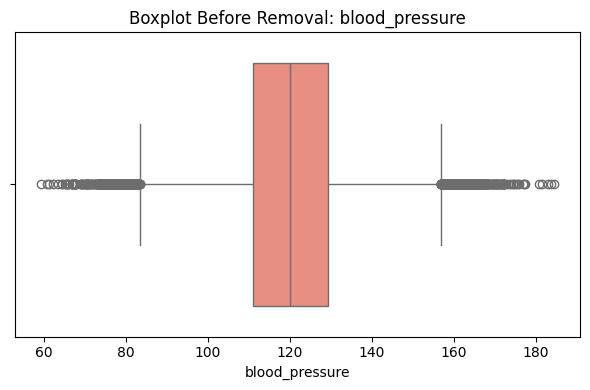

blood_pressure: Removed 1216 outliers


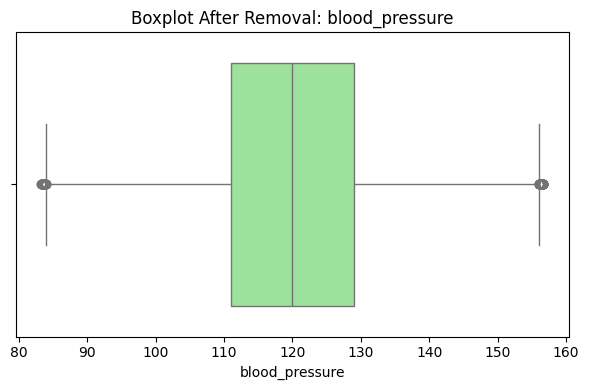

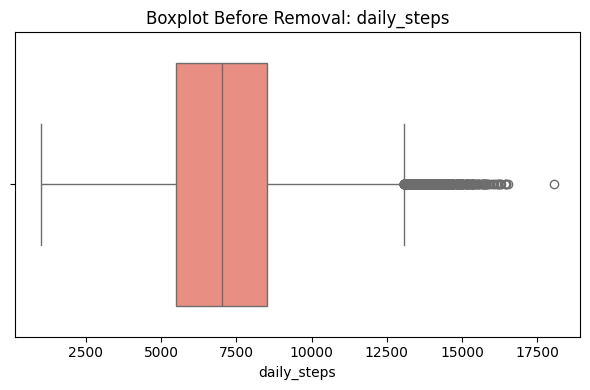

daily_steps: Removed 639 outliers


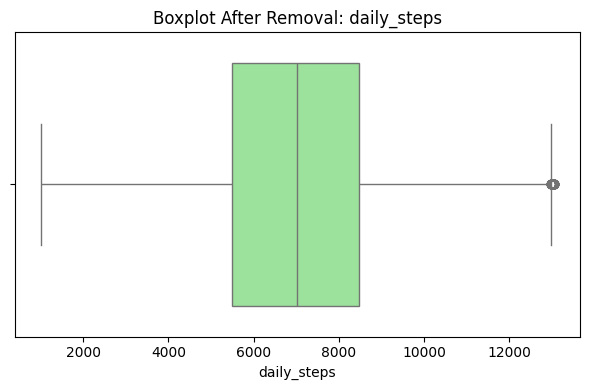

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Define the IQR-based outlier removal function with box plots
def remove_outliers_iqr(df, column):
    # 📦 Boxplot before removal
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[column], color='salmon')
    plt.title(f'Boxplot Before Removal: {column}')
    plt.tight_layout()
    plt.show()

    # ✂️ IQR filtering
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    removed = df.shape[0] - filtered_df.shape[0]
    print(f"{column}: Removed {removed} outliers")

    # 📦 Boxplot after removal
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=filtered_df[column], color='lightgreen')
    plt.title(f'Boxplot After Removal: {column}')
    plt.tight_layout()
    plt.show()

    return filtered_df

# Step 2: Define target columns for outlier removal
outlier_cols = [
    'survey_code', 'age', 'height', 'weight', 'bmi', 'bmi_estimated', 'bmi_scaled',
    'bmi_corrected', 'waist_size', 'cholesterol', 'glucose', 'sleep_hours', 'work_hours',
    'physical_activity', 'calorie_intake', 'sugar_intake', 'water_intake', 'screen_time', 'stress_level',
    'mental_health_score', 'daily_supplement_dosage', 'heart_rate', 'blood_pressure', 'daily_steps'
]

# Step 3: Apply outlier removal iteratively
for col in outlier_cols:
    if col in df.columns:
        df = remove_outliers_iqr(df, col)
    else:
        print(f"⚠️ Column '{col}' not found in DataFrame")

In [42]:
#4- Feature Scale and Normalize - IT24100418

In [43]:
# Select numeric columns (excluding binary/categorical)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns for scaling:", numeric_cols)

Numeric columns for scaling: ['survey_code', 'age', 'height', 'weight', 'bmi', 'bmi_estimated', 'bmi_scaled', 'bmi_corrected', 'waist_size', 'cholesterol', 'glucose', 'sleep_hours', 'work_hours', 'physical_activity', 'calorie_intake', 'sugar_intake', 'water_intake', 'screen_time', 'stress_level', 'mental_health_score', 'meals_per_day', 'electrolyte_level', 'environmental_risk_score', 'daily_supplement_dosage', 'heart_rate', 'blood_pressure', 'daily_steps', 'gender_encoded', 'sleep_quality_encoded', 'smoking_level_encoded', 'mental_health_support_encoded', 'education_level_encoded', 'device_usage_encoded', 'healthcare_access_encoded', 'insurance_encoded', 'sunlight_exposure_encoded', 'family_history_encoded', 'pet_owner_encoded', 'target_encoded']


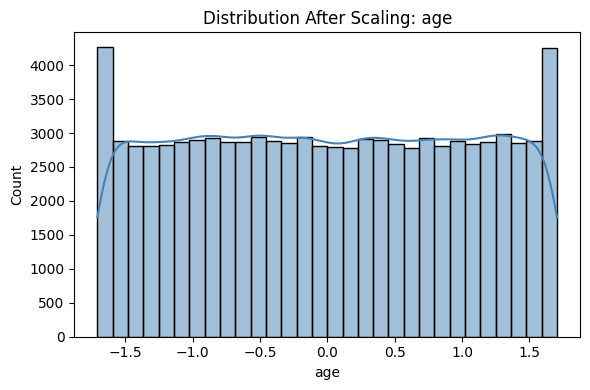

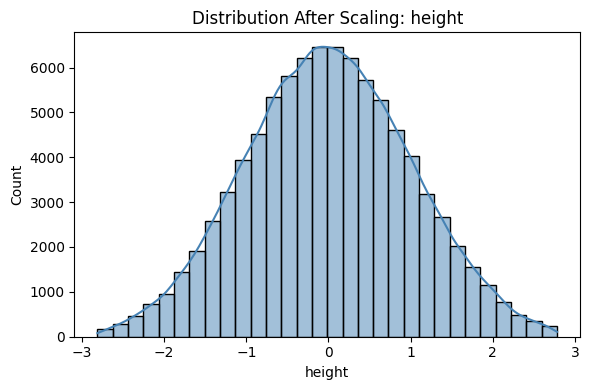

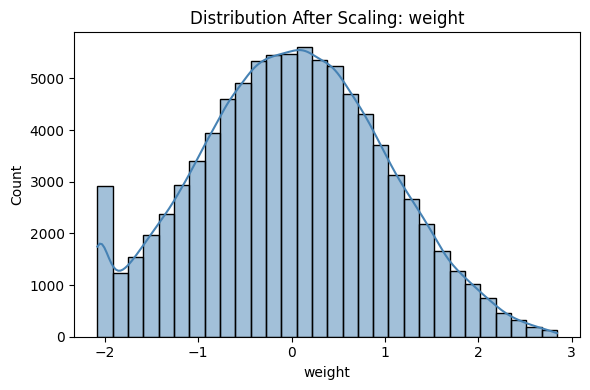

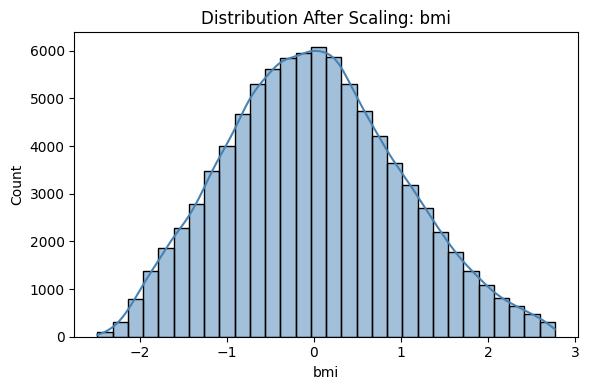

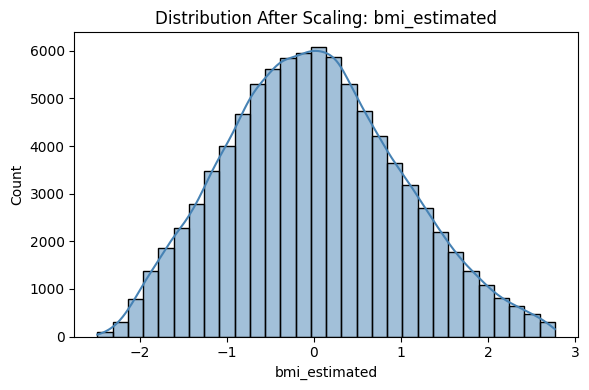

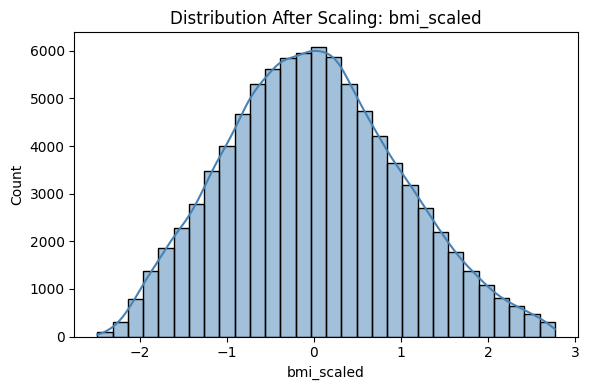

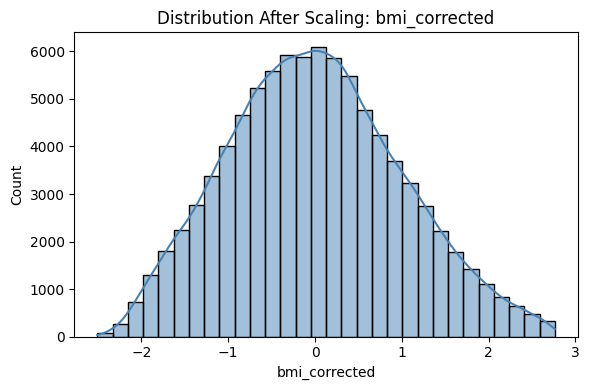

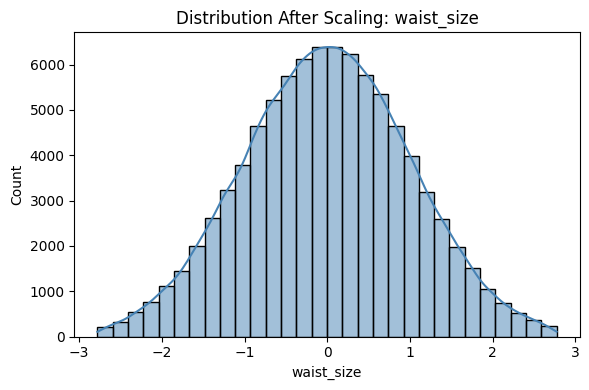

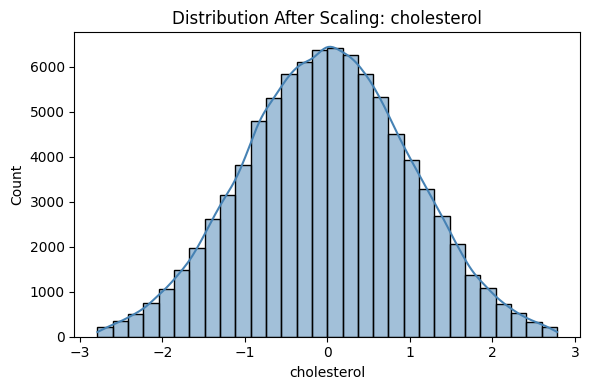

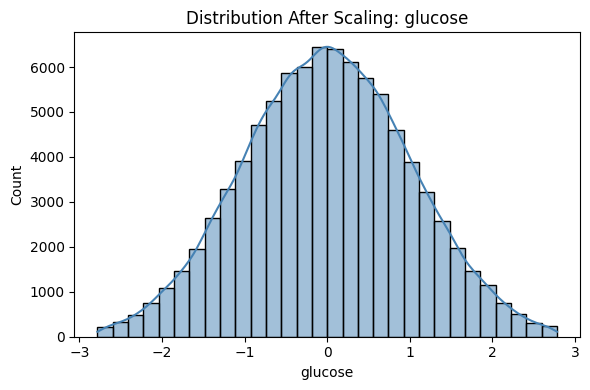

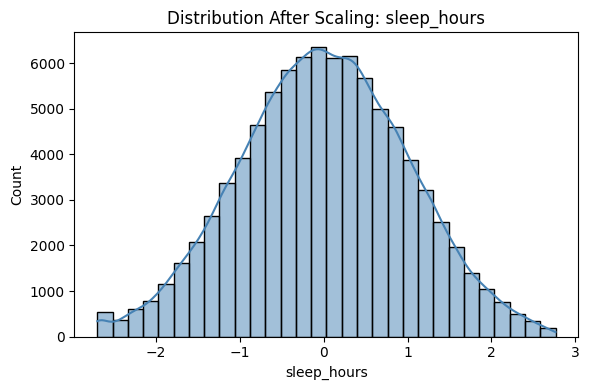

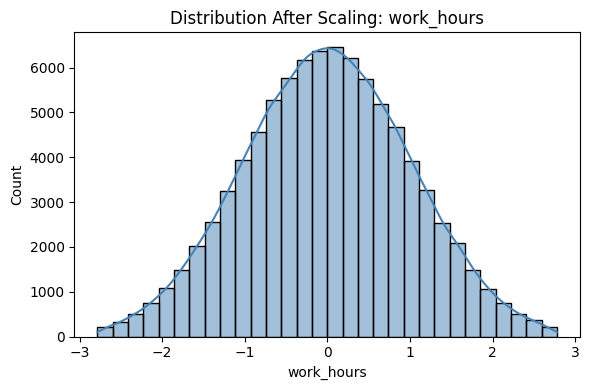

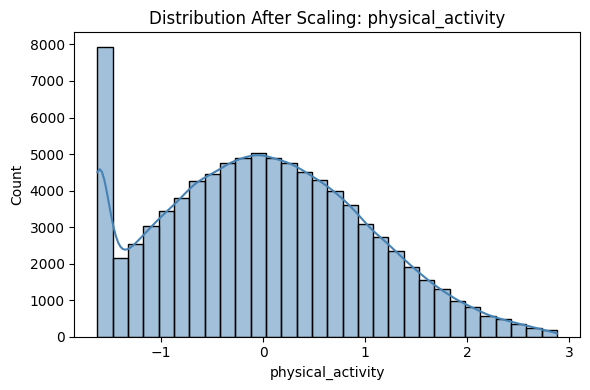

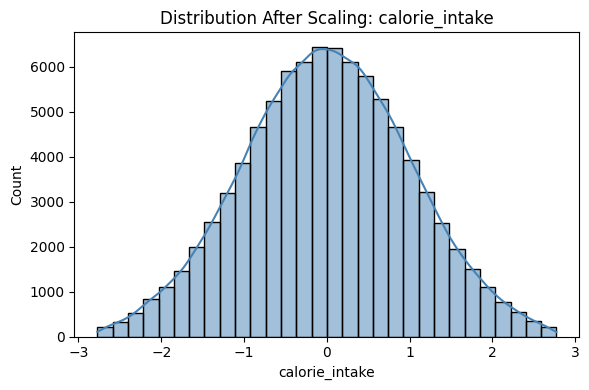

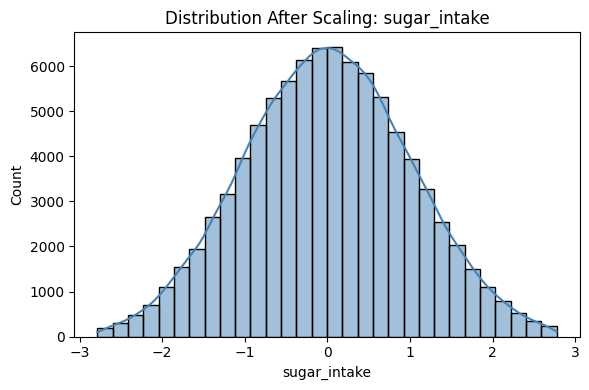

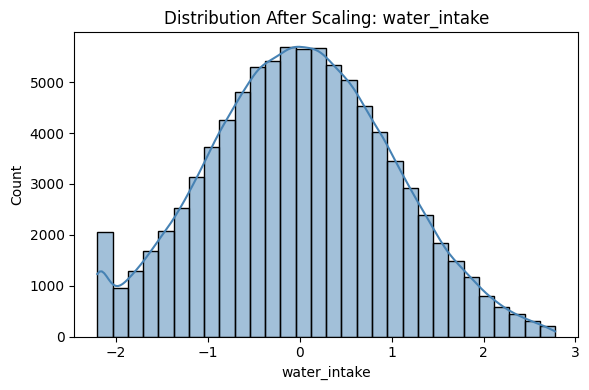

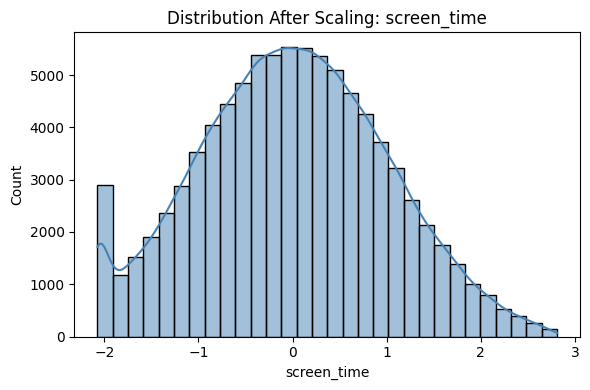

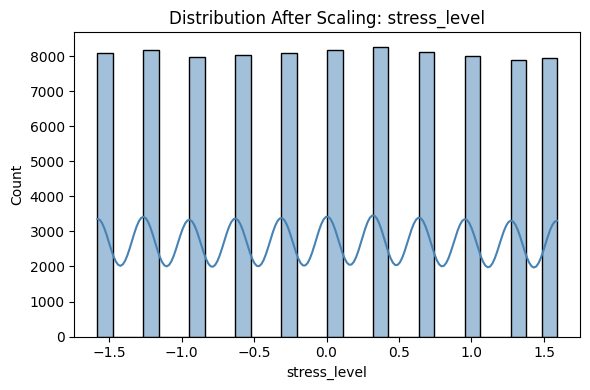

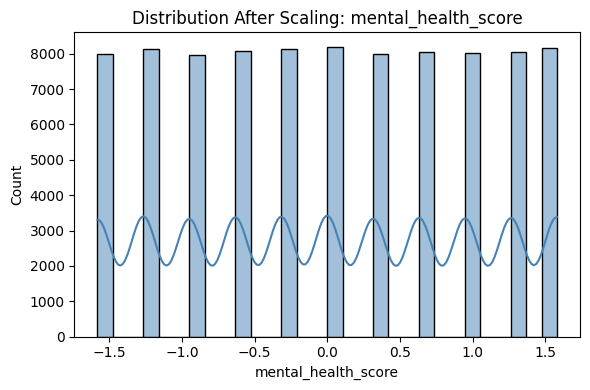

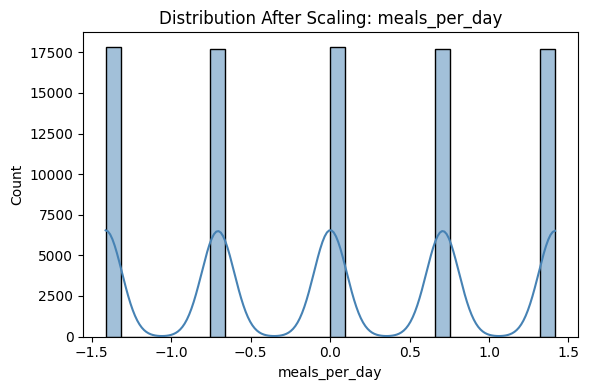

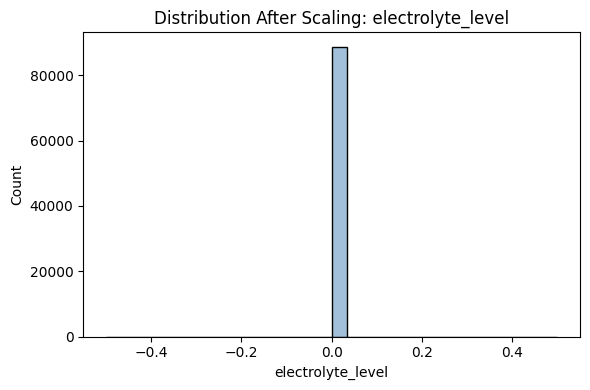

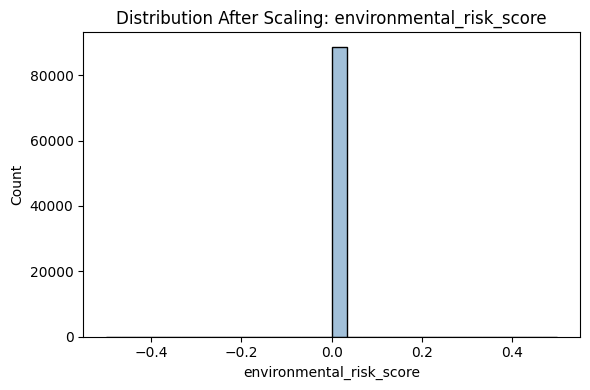

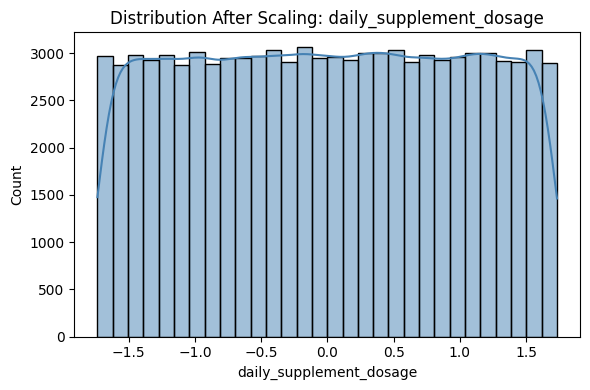

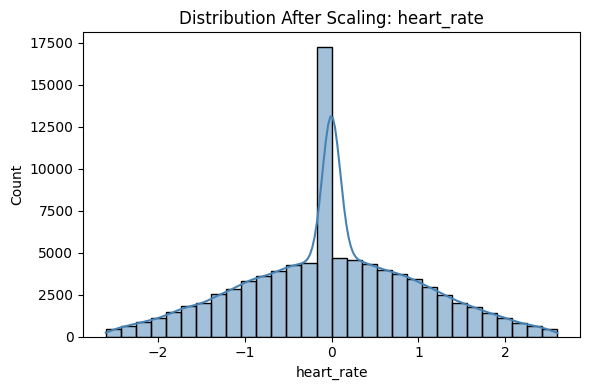

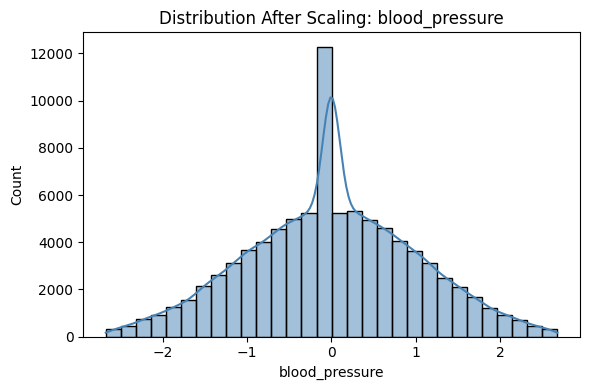

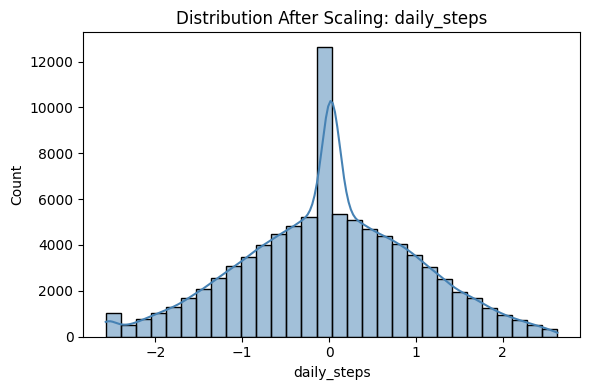

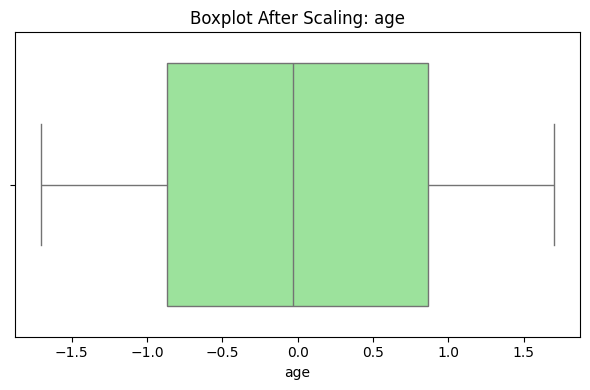

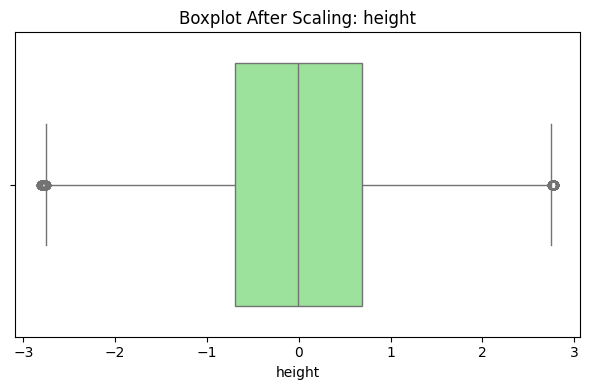

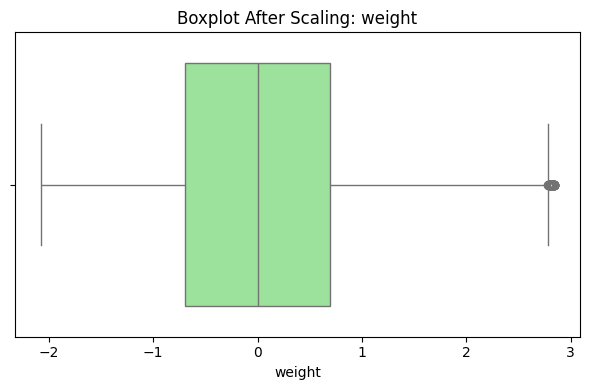

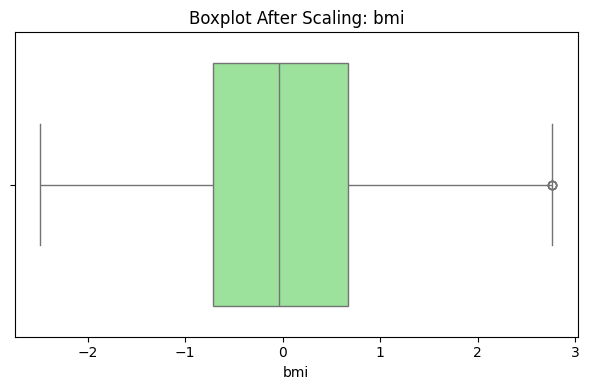

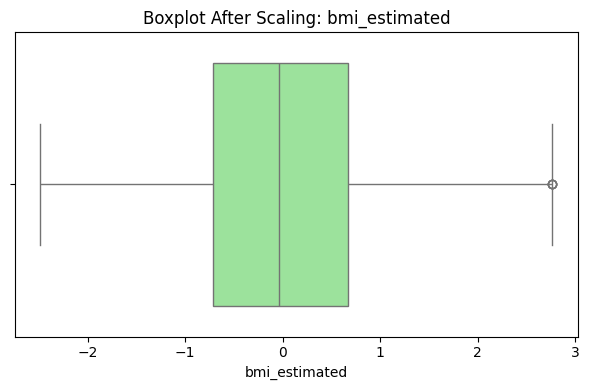

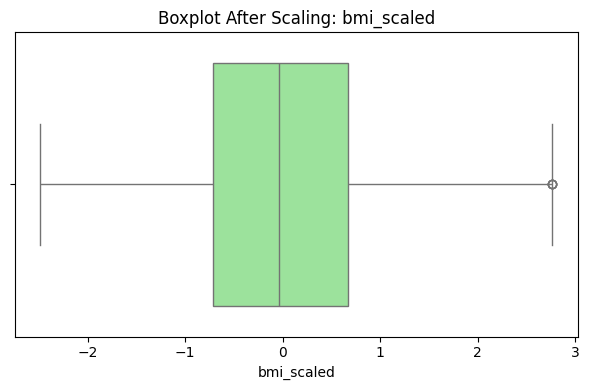

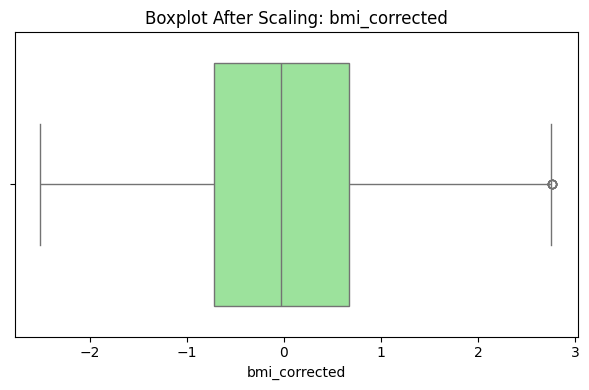

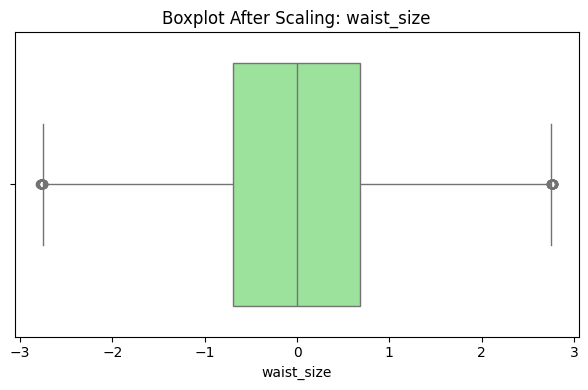

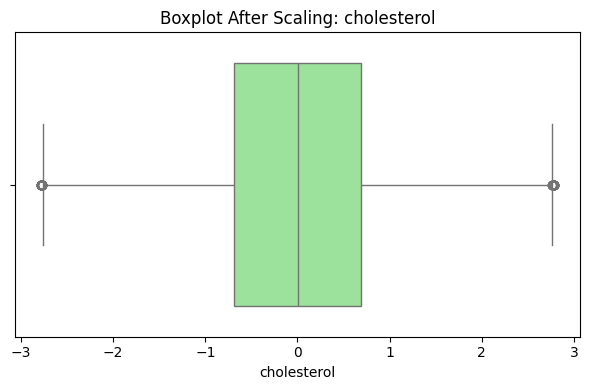

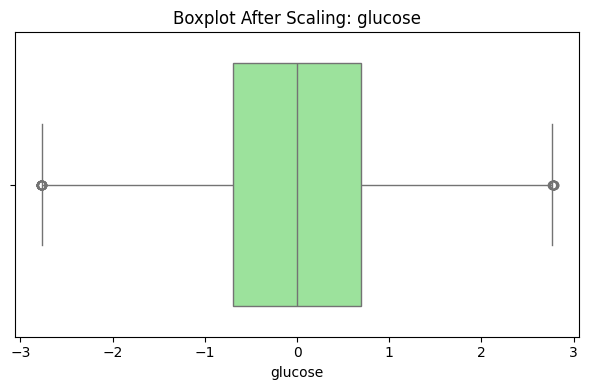

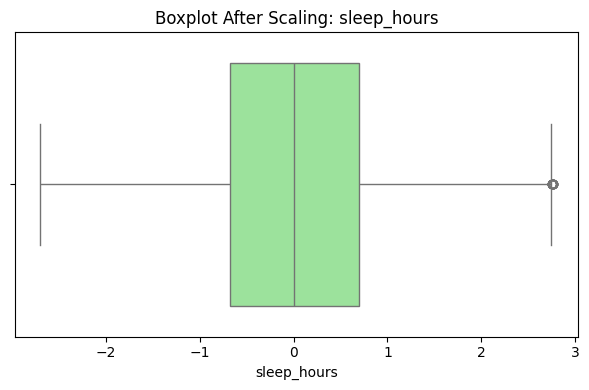

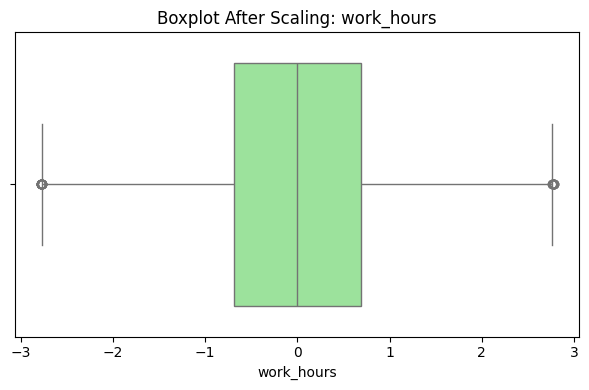

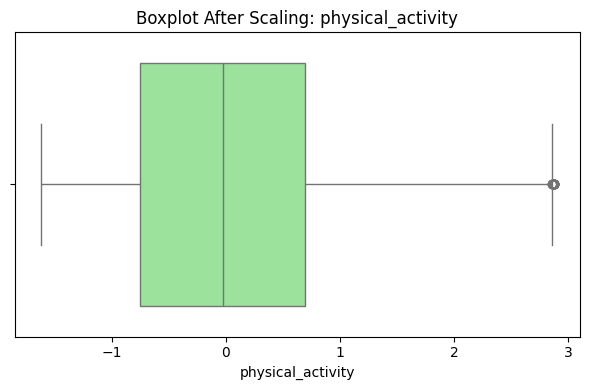

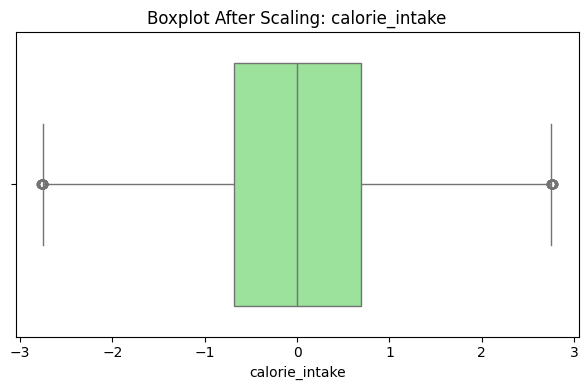

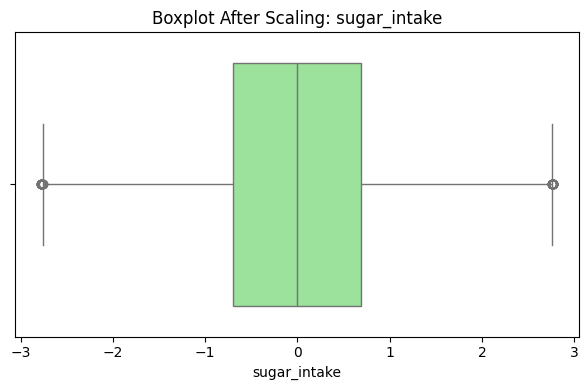

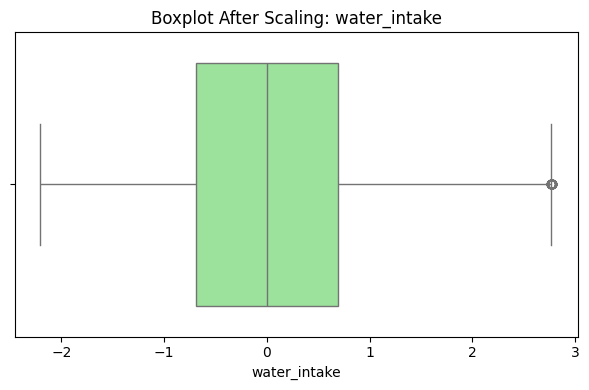

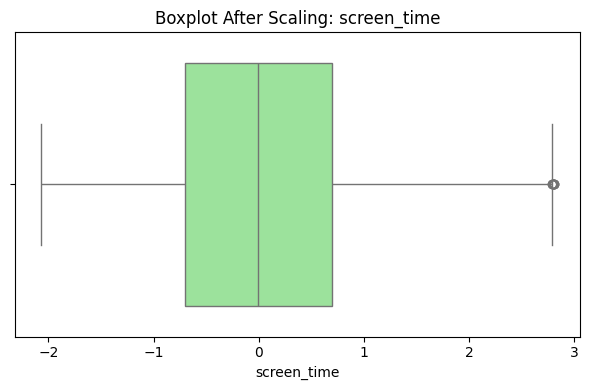

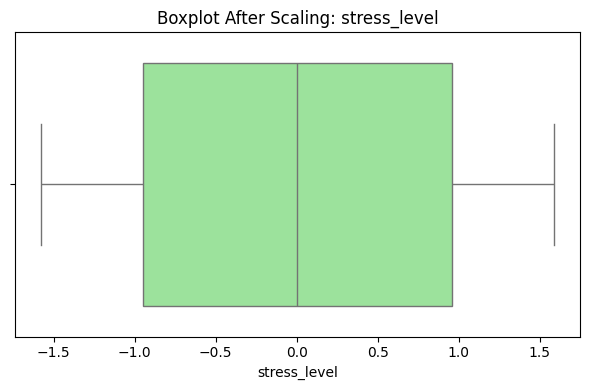

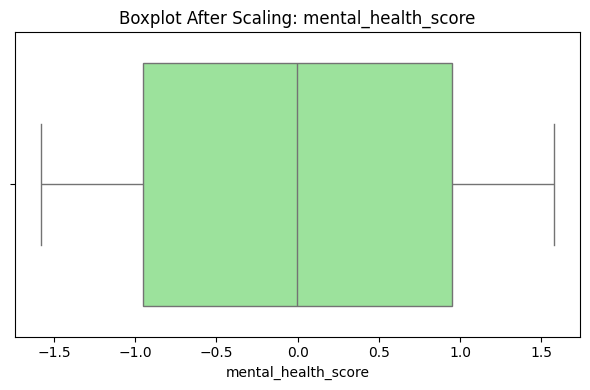

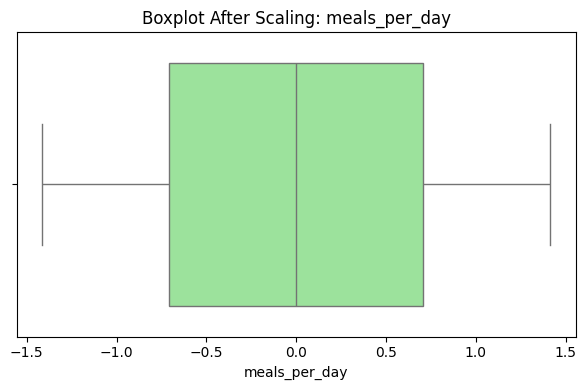

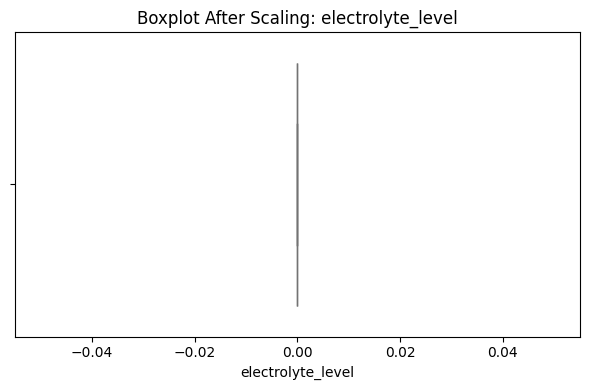

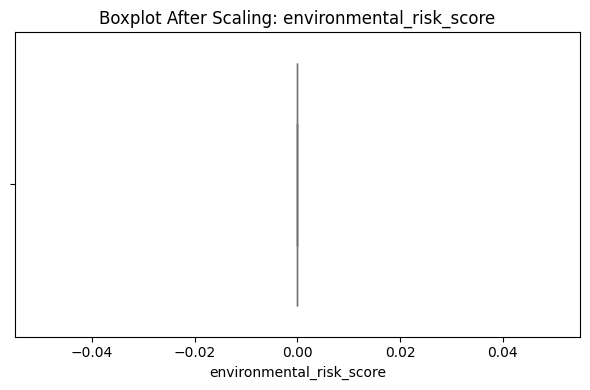

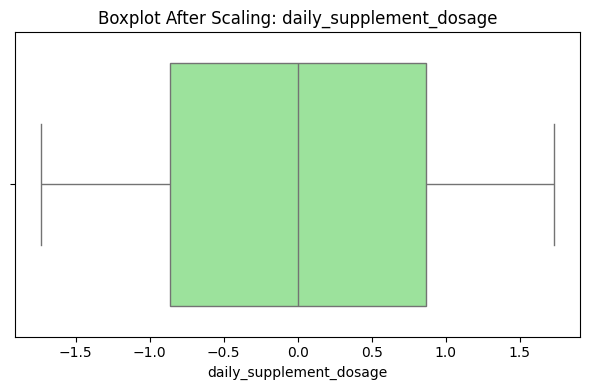

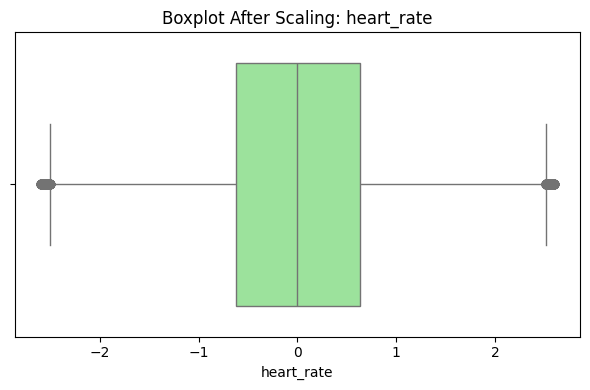

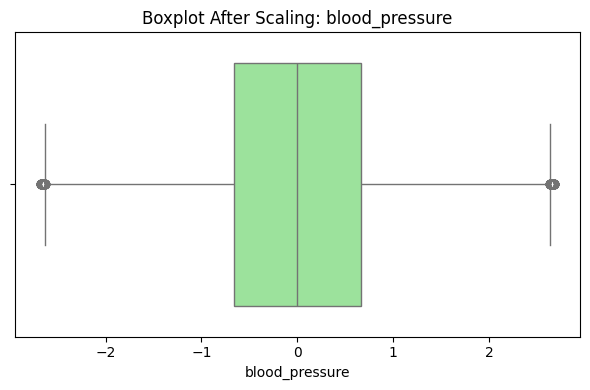

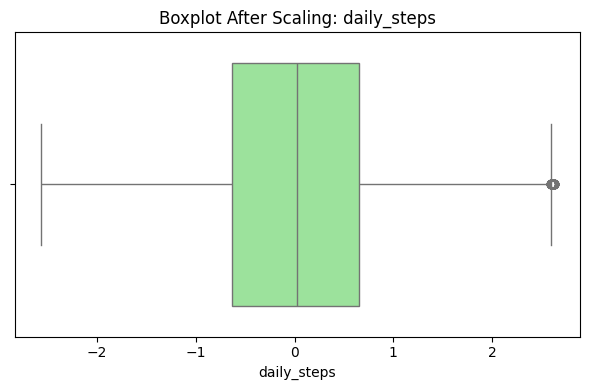

C:\Users\PASINDU VIHANGA\AppData\Local\Temp\ipykernel_13788\1048128794.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='Set2')


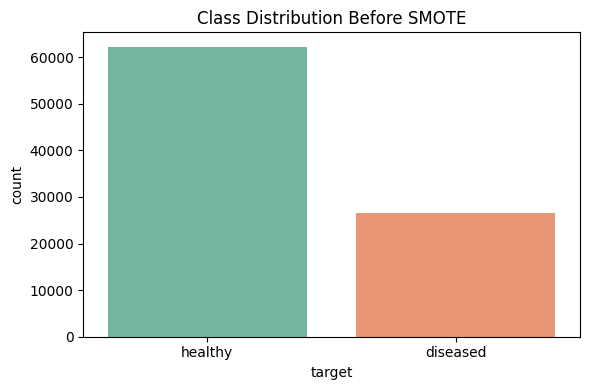

C:\Users\PASINDU VIHANGA\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\PASINDU VIHANGA\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\PASINDU VIHANGA\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\PASINDU VIHANGA\AppData\Local\Program

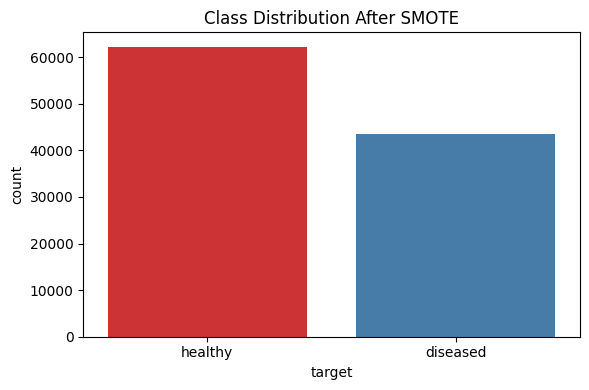

Scaled columns:
                age        height        weight           bmi  bmi_estimated  \
count  8.875500e+04  8.875500e+04  8.875500e+04  8.875500e+04   8.875500e+04   
mean  -8.165778e-18  5.617575e-16  3.909966e-16 -2.241586e-17  -2.241586e-17   
std    1.000006e+00  1.000006e+00  1.000006e+00  1.000006e+00   1.000006e+00   
min   -1.706860e+00 -2.812742e+00 -2.079012e+00 -2.485352e+00  -2.485352e+00   
25%   -8.680448e-01 -6.897806e-01 -6.964811e-01 -7.187524e-01  -7.187524e-01   
50%   -2.922976e-02 -4.825881e-03  4.162347e-03 -3.486413e-02  -3.486413e-02   
75%    8.655063e-01  6.864224e-01  6.957333e-01  6.731591e-01   6.731591e-01   
max    1.704321e+00  2.782030e+00  2.843697e+00  2.764534e+00   2.764534e+00   

         bmi_scaled  bmi_corrected    waist_size   cholesterol       glucose  \
count  8.875500e+04   8.875500e+04  8.875500e+04  8.875500e+04  8.875500e+04   
mean  -2.443329e-16  -6.875265e-16 -1.479447e-16  5.123625e-16 -1.976599e-16   
std    1.000006e+00   1

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# ✅ Step 1: Define the columns to scale
scale_cols = [
    'age', 'height', 'weight', 'bmi', 'bmi_estimated', 'bmi_scaled', 'bmi_corrected',
    'waist_size', 'cholesterol', 'glucose', 'sleep_hours', 'work_hours',
    'physical_activity', 'calorie_intake', 'sugar_intake', 'water_intake',
    'screen_time', 'stress_level', 'mental_health_score', 'meals_per_day',
    'electrolyte_level', 'environmental_risk_score', 'daily_supplement_dosage',
    'heart_rate', 'blood_pressure', 'daily_steps'
]

# ✅ Step 2: Keep only the columns that exist in the current DataFrame
existing_cols = [col for col in scale_cols if col in df.columns]

# ✅ Step 3: Apply StandardScaler to normalize selected columns
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[existing_cols] = scaler.fit_transform(df[existing_cols])

# 📊 Step 3.5: Visualize scaled distributions
for col in existing_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df_scaled[col], kde=True, bins=30, color='steelblue')
    plt.title(f'Distribution After Scaling: {col}')
    plt.tight_layout()
    plt.show()

# 📦 Step 3.6: Box plots to inspect outliers
for col in existing_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df_scaled[col], color='lightgreen')
    plt.title(f'Boxplot After Scaling: {col}')
    plt.tight_layout()
    plt.show()

# ✅ Step 4: Define feature matrix and target vector
X_scaled = df_scaled[existing_cols]
y = df['target']  # Replace 'target' with your actual label column name

# 📈 Step 4.5: Visualize class imbalance before SMOTE
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette='Set2')
plt.title("Class Distribution Before SMOTE")
plt.tight_layout()
plt.show()

# ✅ Step 5: Apply SMOTE to reduce class imbalance
smote = SMOTE(random_state=24, sampling_strategy=0.7)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# 📈 Step 5.5: Visualize class distribution after SMOTE
plt.figure(figsize=(6, 4))
sns.countplot(x=y_resampled, palette='Set1')
plt.title("Class Distribution After SMOTE")
plt.tight_layout()
plt.show()

# ✅ Step 6: Confirm scaling results with summary statistics
print("Scaled columns:")
print(df_scaled[existing_cols].describe())

In [45]:
df = df_scaled
df.head()

,survey_code,age,gender,height,weight,bmi,bmi_estimated,bmi_scaled,bmi_corrected,waist_size,...,occupation_Engineer,occupation_Farmer,occupation_Teacher,device_usage_encoded,healthcare_access_encoded,insurance_encoded,sunlight_exposure_encoded,family_history_encoded,pet_owner_encoded,target_encoded
1,2,1.145111,Female,-0.724865,1.970790,2.215676,2.215676,2.215676,2.177921,0.055271,...,True,False,False,1.0,1.0,0,2.0,1,0,1
2,3,-0.141072,Male,0.742255,0.771800,0.248481,0.248481,0.248481,0.233058,0.456999,...,False,False,True,2.0,2.0,1,2.0,0,0,1
3,4,-0.923966,Female,0.202223,-0.457485,-0.527224,-0.527224,-0.527224,-0.552138,1.330334,...,False,False,True,0.0,1.0,0,2.0,0,1,1
4,5,0.641822,Female,-0.683019,-2.079012,-1.662872,-1.662872,-1.662872,-1.679607,-1.362857,...,False,False,False,0.0,1.0,1,2.0,1,1,1
6,7,1.648400,Female,-0.416593,-0.324896,-0.128938,-0.128938,-0.128938,-0.146991,-1.464036,...,True,False,False,1.0,0.0,1,2.0,0,0,1


In [46]:
#5- Feature Selection - IT24100390

In [47]:
from sklearn.feature_selection import VarianceThreshold

# Remove features with variance below 0.01
selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(df.select_dtypes(include=[np.number]))

# Get selected column names
selected_cols = df.select_dtypes(include=[np.number]).columns[selector.get_support()]
print("Selected by variance:", selected_cols.tolist())


Selected by variance: ['survey_code', 'age', 'height', 'weight', 'bmi', 'bmi_estimated', 'bmi_scaled', 'bmi_corrected', 'waist_size', 'cholesterol', 'glucose', 'sleep_hours', 'work_hours', 'physical_activity', 'calorie_intake', 'sugar_intake', 'water_intake', 'screen_time', 'stress_level', 'mental_health_score', 'meals_per_day', 'daily_supplement_dosage', 'heart_rate', 'blood_pressure', 'daily_steps', 'gender_encoded', 'sleep_quality_encoded', 'smoking_level_encoded', 'mental_health_support_encoded', 'education_level_encoded', 'device_usage_encoded', 'healthcare_access_encoded', 'insurance_encoded', 'sunlight_exposure_encoded', 'family_history_encoded', 'pet_owner_encoded', 'target_encoded']


In [48]:
desired_cols = [
    'age', 'height', 'weight', 'bmi', 'waist_size', 'glucose', 'sleep_hours',
    'physical_activity', 'water_intake', 'meals_per_day', 'heart_rate',
    'blood_pressure', 'daily_steps', 'gender_encoded', 'family_history_encoded',
    'target_encoded'
]

# Your full variance-filtered list
variance_selected = [
    'survey_code', 'age', 'height', 'weight', 'bmi', 'bmi_estimated', 'bmi_scaled',
    'bmi_corrected', 'waist_size', 'cholesterol', 'glucose', 'sleep_hours',
    'work_hours', 'physical_activity', 'calorie_intake', 'sugar_intake',
    'water_intake', 'screen_time', 'stress_level', 'mental_health_score',
    'meals_per_day', 'daily_supplement_dosage', 'heart_rate', 'blood_pressure',
    'daily_steps', 'gender_encoded', 'sleep_quality_encoded', 'smoking_level_encoded',
    'mental_health_support_encoded', 'education_level_encoded', 'device_usage_encoded',
    'healthcare_access_encoded', 'insurance_encoded', 'sunlight_exposure_encoded',
    'family_history_encoded', 'pet_owner_encoded', 'target_encoded'
]

# Filter only the desired ones
selected_features = [col for col in desired_cols if col in variance_selected]
print("Final selected features:", selected_features)

df_selected = df[selected_features]
df=df_selected

Final selected features: ['age', 'height', 'weight', 'bmi', 'waist_size', 'glucose', 'sleep_hours', 'physical_activity', 'water_intake', 'meals_per_day', 'heart_rate', 'blood_pressure', 'daily_steps', 'gender_encoded', 'family_history_encoded', 'target_encoded']


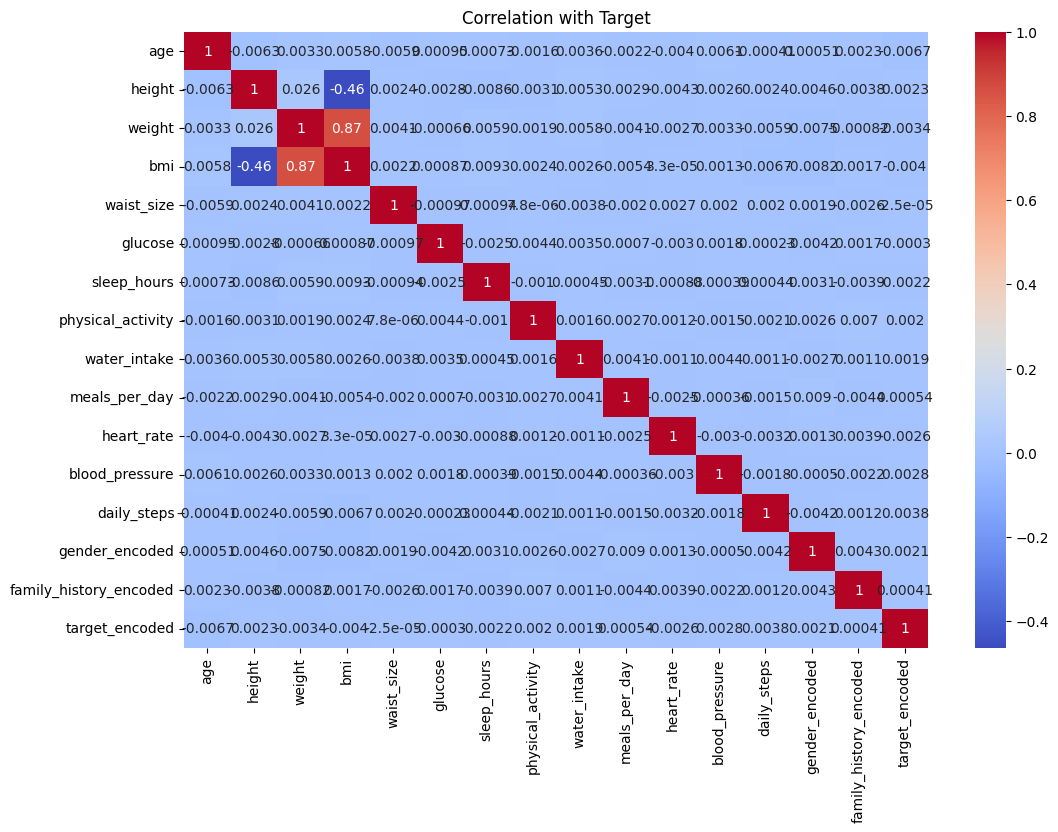

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

# Remove 'target_encoded' if it's already in selected_features
features_to_plot = [f for f in selected_features if f != 'target_encoded']

# Add 'target_encoded' back explicitly for correlation
features_to_plot.append('target_encoded')

plt.figure(figsize=(12, 8))
sns.heatmap(df[features_to_plot].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation with Target")
plt.show()

In [50]:
#6- Dimensionality Reduction(PCA) - IT24100419

Original feature count: 15
Reduced feature count: 14
Explained variance ratio per component:
[0.132 0.069 0.068 0.068 0.067 0.067 0.067 0.067 0.067 0.067 0.066 0.066
 0.066 0.065]


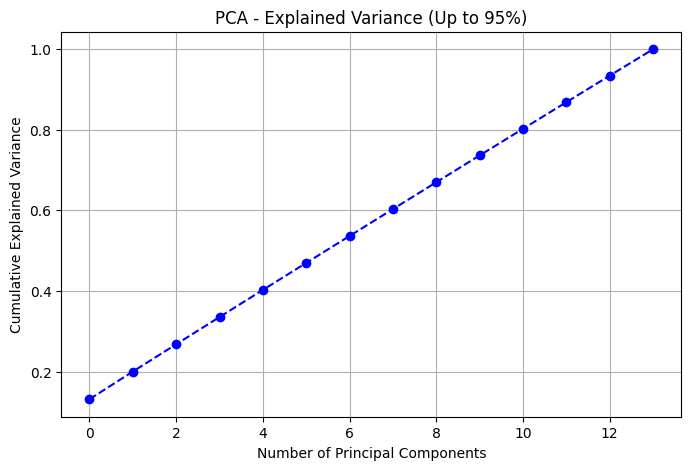

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,target
0,3.034327,-0.172964,0.697045,-1.273303,0.206085,0.930060,-1.115248,1.522548,-1.524883,-0.279473,1.141601,-0.181755,1.248357,2.476128,1
1,0.409618,1.464602,-0.637696,1.372340,0.963154,-0.169627,0.977803,-0.940672,0.009408,0.121713,-0.430508,0.609755,-0.542395,-0.661521,1
2,-0.711474,1.241671,0.942262,-1.554321,-0.945969,0.481455,2.834547,-0.234487,-0.011874,0.248332,0.508775,-0.845280,-1.257075,-1.038882,1
3,-2.234661,-1.942115,1.387957,-1.162644,-0.921340,-1.997464,0.344971,0.190203,0.718564,1.440051,-0.654120,-1.556619,1.585597,0.094420,1
4,-0.174677,-0.439772,1.075733,-1.733061,-0.055735,0.074989,-1.222875,-1.836205,-2.077822,0.067609,0.000756,1.192212,0.170279,-0.719877,1


In [51]:
# 6 - Dimensionality Reduction using PCA (Corrected & Robust)
# ------------------------------------------------------------
# IT24100500

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Step 1: Identify features and target
# Replace 'target' with your actual target column name
X = df.drop('target_encoded', axis=1)
y = df['target_encoded']

# Step 2: Handle categorical columns (encode them)
# -------------------------------------------------
# Automatically encode any categorical (non-numeric) columns
X_encoded = X.copy()
for col in X_encoded.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

# Step 3: Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Step 4: Apply PCA (retain 95% of variance)
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Step 5: Inspect results
print(f"Original feature count: {X.shape[1]}")
print(f"Reduced feature count: {X_pca.shape[1]}")
print("Explained variance ratio per component:")
print(np.round(pca.explained_variance_ratio_, 3))

# Step 6: Visualize explained variance
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--', color='b')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance (Up to 95%)')
plt.grid(True)
plt.show()

# Step 7: Create PCA DataFrame
pca_columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pca_columns)
df_pca['target'] = y.values

# Step 8: Display sample of reduced data
df_pca.head()


In [74]:
print(df.columns)

Index(['age', 'height', 'weight', 'bmi', 'waist_size', 'glucose',
       'sleep_hours', 'physical_activity', 'water_intake', 'meals_per_day',
       'heart_rate', 'blood_pressure', 'daily_steps', 'gender_encoded',
       'family_history_encoded', 'target_encoded'],
      dtype='object')


In [86]:
#Model_Selection
#IT24100418_XGBoost_Model

In [91]:
#1

In [92]:
# Train a Classification Model (XGBoost)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import joblib
import matplotlib.pyplot as plt

# Encode the target labels ('healthy', 'diseased') into numeric values
le = LabelEncoder()
y_resampled_encoded = le.fit_transform(y_resampled)

# Split the balanced data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled_encoded, test_size=0.2, random_state=42, stratify=y_resampled_encoded
)

# Initialize the XGBoost model
model = XGBClassifier(
    n_estimators=200,         # number of boosting rounds (trees)
    learning_rate=0.05,       # smaller learning rate for stable training
    max_depth=5,              # depth of each tree
    subsample=0.8,            # fraction of samples used per tree
    colsample_bytree=0.8,     # fraction of features per tree
    random_state=42,
    eval_metric="logloss",    # evaluation metric
    use_label_encoder=False
)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Convert predictions & test labels back to original text labels
y_pred_labels = le.inverse_transform(y_pred)
y_test_labels = le.inverse_transform(y_test)

# Evaluate performance
print("Model Evaluation Results:")
print("Accuracy:", round(accuracy_score(y_test_labels, y_pred_labels), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_labels, y_pred_labels))
print("\nClassification Report:\n", classification_report(y_test_labels, y_pred_labels))

C:\Users\PASINDU VIHANGA\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [08:57:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model Evaluation Results:
Accuracy: 0.7371

Confusion Matrix:
 [[ 3150  5563]
 [    0 12447]]

Classification Report:
               precision    recall  f1-score   support

    diseased       1.00      0.36      0.53      8713
     healthy       0.69      1.00      0.82     12447

    accuracy                           0.74     21160
   macro avg       0.85      0.68      0.67     21160
weighted avg       0.82      0.74      0.70     21160



In [93]:
#2

Columns in dataset: Index(['age', 'height', 'weight', 'bmi', 'waist_size', 'glucose',
       'sleep_hours', 'physical_activity', 'water_intake', 'meals_per_day',
       'heart_rate', 'blood_pressure', 'daily_steps', 'gender_encoded',
       'family_history_encoded', 'target_encoded'],
      dtype='object')
Target column changed to: target_encoded
Fitting 5 folds for each of 24 candidates, totalling 120 fits


C:\Users\PASINDU VIHANGA\AppData\Local\Temp\ipykernel_13788\2750191814.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[target_col] = label_encoder.fit_transform(df[target_col])
C:\Users\PASINDU VIHANGA\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [09:00:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGBoost Parameters: {'clf__learning_rate': 0.05, 'clf__max_depth': 5, 'clf__n_estimators': 100, 'clf__subsample': 0.8}


C:\Users\PASINDU VIHANGA\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [09:01:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      5304
           1       0.70      1.00      0.82     12447

    accuracy                           0.70     17751
   macro avg       0.35      0.50      0.41     17751
weighted avg       0.49      0.70      0.58     17751

Confusion Matrix:
 [[    0  5304]
 [    0 12447]]


C:\Users\PASINDU VIHANGA\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\PASINDU VIHANGA\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\PASINDU VIHANGA\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 


 Random Forest Results:
              precision    recall  f1-score   support

           0       0.35      0.00      0.01      5304
           1       0.70      1.00      0.82     12447

    accuracy                           0.70     17751
   macro avg       0.53      0.50      0.42     17751
weighted avg       0.60      0.70      0.58     17751

Confusion Matrix:
 [[   18  5286]
 [   33 12414]]

 Tuned XGBoost Results:


C:\Users\PASINDU VIHANGA\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\PASINDU VIHANGA\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\PASINDU VIHANGA\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      5304
           1       0.70      1.00      0.82     12447

    accuracy                           0.70     17751
   macro avg       0.35      0.50      0.41     17751
weighted avg       0.49      0.70      0.58     17751

Confusion Matrix:
 [[    0  5304]
 [    0 12447]]

Final Model Comparison:

                 Model  Accuracy  F1 Score       AUC
0  Logistic Regression  0.701200  0.824359  0.495172
2        Tuned XGBoost  0.701200  0.824359  0.499288
1        Random Forest  0.700355  0.823565  0.499300


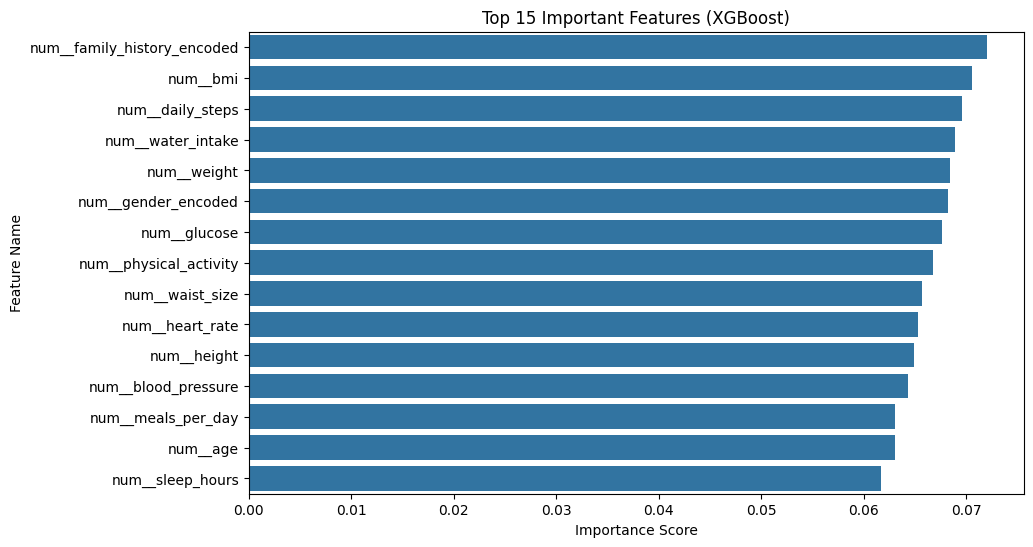

In [94]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Check columns
print("Columns in dataset:", df.columns)

# Identify target column 
target_col = 'Disease'
if target_col not in df.columns:
    target_col = df.columns[-1]
    print(f"Target column changed to: {target_col}")

# Encode target
label_encoder = LabelEncoder()
df[target_col] = label_encoder.fit_transform(df[target_col])

# Features and target
X = df.drop(target_col, axis=1)
y = df[target_col]


# Identify numerical & categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns


# Preprocessing: Scaling + Encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# Define Models
log_model = Pipeline([
    ('preprocess', preprocessor),
    ('clf', LogisticRegression(max_iter=1000))
])

rf_model = Pipeline([
    ('preprocess', preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])

xgb_model = Pipeline([
    ('preprocess', preprocessor),
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])


# Hyperparameter Tuning (XGBoost)
param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [3, 5, 7],
    'clf__learning_rate': [0.05, 0.1],
    'clf__subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_
print("Best XGBoost Parameters:", grid_xgb.best_params_)


# Train All Models
models = {
    "Logistic Regression": log_model.fit(X_train, y_train),
    "Random Forest": rf_model.fit(X_train, y_train),
    "Tuned XGBoost": best_xgb.fit(X_train, y_train)
}


# Evaluate Models
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'F1 Score': f1,
        'AUC': auc
    })
    
    print(f"\n {name} Results:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


# Comparison Table
results_df = pd.DataFrame(results)
print("\nFinal Model Comparison:\n")
print(results_df.sort_values(by="F1 Score", ascending=False))


# Feature Importance (XGBoost Only)
xgb_final_model = best_xgb.named_steps['clf']
feature_names = best_xgb.named_steps['preprocess'].get_feature_names_out()
importances = xgb_final_model.feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)[:15]
plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Top 15 Important Features (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Feature Name")
plt.show()